# Feature analysis — micro-price premium

This notebook is two things at once: a **method** for analysing a trading feature, and a
**worked example** of that method on one feature. The text explains what to do and why; the
code does it.

We build features for a model that forecasts one exchange's mid-price about 100 ms ahead.
Three crypto exchanges appear throughout — **byb** (Bybit), **bin** (Binance), **okx** (OKX) —
and **byb is the target**: the one we predict. ("Mid-price" = the midpoint between the best
buy and best sell quote.) The next section explains the model these features feed.

To analyse a new feature, copy the template notebook and change the parts specific to the feature:
**what it is and why** (§1), **its exact definition** (§2), and **its builder** (§3). The
data loading, the checks, and the plots adapt on their own.

**The feature here** is the **micro-price premium** — the single strongest L1 next-mid predictor.
Each venue's best-bid/ask sizes tell you which way the touch is *leaning*: a big bid and a thin
ask means buyers crowd the book and the mid is about to tick up. The Stoikov micro-price turns the
two sizes into a fair value between the quotes, and the **premium** `(microprice − mid)/mid` is how
far that fair value sits above or below the current mid. We smooth it per venue (where the touch
leans) and look at the cross-venue **gap** (one venue leaning before byb does) as a lead.

**A feature is "done" when two checks pass:**
- **The oracle (§4)** — the code really computes what we think it does.
- **The hygiene gates (§5)** — the signal is real and holds in any market, not just an echo
  of "the market is volatile right now."

Everything after that decides *which part of the model* the feature feeds, and *at what
time-scale*.

## The model these features feed: two heads

A feature is only worth something if it helps the model predict, so it's worth knowing what
the model does. We forecast how byb's mid-price moves over the next ~100 ms, and we split
that into two simpler questions — the two **heads**:

**Price head — which way and how far?** Over the next few price-moves, what is the *signed*
move (its direction *and* its size, together)? The head predicts the whole distribution of
that move, in units of byb's recent **volatility** — the **volatility yardstick** `σ_ev`
(the exp-weighted RMS of byb's *actual* mid-moves) — so the head's target is
`price change ÷ σ_ev`.

**Rate head — how many moves?** Busy markets pack many price-moves into the window, quiet
ones few. This head predicts the *count* of moves over the next 100 ms as a distribution,
measured against the recent pace — the **rate yardstick** `λ_ev` — so its target is
`count ÷ λ_ev`.

**What's a yardstick?** A causal, trailing estimate of byb's *volatility* (`σ_ev`) and move
*rate* (`λ_ev`), from past data only. A regime gauge, nothing more. When a feature *carries* that regime and you want it gone, dividing
by the yardstick is **one option** for removing it (only *when applicable* — you can't always
divide the regime out of a feature). Both are EMAs **decayed on the trade clock** (`α = 2/(span+1)`)
but **updated between trades** — they react to every byb mid-move, so they read live at every
instant. They use one fixed span, `YARDSTICK_N` (any feature may use that span too). (`σ_ev` is
the exp-weighted RMS of byb's *actual* mid-moves — read as an `E/W` ratio so the many non-move
trades cancel out; `λ_ev` is a ratio of two EMAs — the exp-weighted byb move-count `W` (the same
`W` that is `σ_ev`'s denominator) ÷ the exp-weighted seconds-per-trade = byb's moves per second.) Like every average here, they live
on the trade-tick clock — never wall-clock or a hard window.

**Why split into two heads?** A move over a window is just *how many* little moves happen
times *how big* each one is. Pulling "how many" (rate) apart from "how big" (price) lets each
head learn a steadier thing — and is why there are two yardsticks, one per head.

**Putting them back together.** The price head isn't a single distribution — it's a *family*,
one per possible move-count: "if `k` moves happen, here's the spread of the total price
change" (call it `D_k`). The rate head gives the probability of each count, `P(K = k)`. The
100 ms move is the two **mixed** — for every count `k`, take the price head's `k`-move
distribution, weight it by the rate head's probability of exactly `k` moves, and sum:

`distribution of the 100 ms move  =  Σ_k  P(K = k) · D_k`

More moves → a wider spread, so the rate head's "how many" sets the scale and the price head's
`D_k` sets the shape. This is why a feature that predicts the *count* (rate head) and one that
predicts the *per-move direction* (price head) are both useful: they feed the two factors that
multiply together.

**Backed by research.** This "how many × how big" split is the classic **subordination** model
of asset prices (Clark, 1973, *Econometrica*; Ané & Geman, 2000, *Journal of Finance*): returns
over a fixed clock-time window look messy, but become well-behaved once you condition on the
*number* of events. So modelling the event count and the per-event move separately, then mixing
them, is a principled decomposition — not just a convenient one.

Every feature here feeds one or both heads, and borrows the matching yardstick when it needs
to be made comparable across markets. Two questions recur below: does a feature's *signed*
value predict the move (price head), and does its *magnitude* predict how many moves come
(rate head)? Those are diagnostics — the model is fed the **signed** feature for *both* heads,
and the rate head learns the magnitude (and how features cancel or reinforce) on its own.

## Guard rails — do this, not that

Hard rules, learned the hard way. Follow them unless you have a specific, written reason not to.

**Don't**
- **Don't assume a fixed leader.** No exchange always leads — leadership moves around. Build
  the feature the same way for every exchange and keep them all.
- **Don't pick "the best exchange"** by average score — that throws away the moments another
  exchange leads (often the most informative ones). Keep all; let the model weight them.
- **Don't pool exchanges by default.** Pooling can blur the cross-exchange structure. For a
  poolable feature, first check per-exchange vs single vs pooled across time-scales (§9).
- **Don't normalize reflexively.** Divide volatility or rate out of a feature *only when it
  needs it* — a ratio or imbalance is already comparable across markets. (This feature is a
  bounded ratio; §2 and §5 *measure* its invariance before deciding — see "raw first".)
- **Don't invent your own vol/rate scale.** When you do normalize, use the model's yardstick
  (`σ_ev` or `λ_ev`), so the feature shares units with the target.
- **Don't trust a correlation** until it survives the regime controls (rate and vol) — else
  it may just be re-reporting "the market is volatile."
- **Don't ship a feature without the oracle** (§4) matching a dead-simple independent version.
- **Don't peek ahead.** Every value uses only data at-or-before its own timestamp.
- **Don't over-transform for the network.** Pick the lightest reshaping that works.

**Do**
- **Do start with a falsifiable hypothesis** — a mechanism for why it should work, and what
  would prove it wrong.
- **Do make every average a trade-tick EMA.** *Every* smoother in the pipeline — the per-venue
  premium legs, the cross-venue gap, `σ_ev`, `λ_ev` — is an exponential moving average
  **decayed once per trade-timestamp** (`α = 2/(span+1)`) yet **updated on every live event between trades** (a fresh book, a byb move — never stale), **never** a wall-clock
  average and **never** a hard/boxcar window. That keeps the whole state **O(1)** (one scalar
  per average, no ring buffers) and bit-identical online vs offline. Establish and validate the
  convention against a plain one-event-at-a-time loop on a real block — exactly as
  `notebooks/03_ema_clock_validation.ipynb` does, and as the §4 oracle re-checks here.
- **Do make every EMA react to *every* relevant event — never let it read a stale state.** An EMA's
  *decay* lives on the trade clock, but it must *update* on every event that can change its value,
  **even between trade ticks**: a premium leg refreshes on every book update; a flow injects on every
  real move. A value that ignores the events since the last trade is **stale** — wrong, and a silent
  source of lag. The choice of EMA *and when it updates* is what makes the inter-trade read
  well-behaved — pick both deliberately (see the "Choosing the EMA" section).
- **Do treat all records sharing a timestamp as ONE event, not a sequence.** A burst of book updates
  and trades stamped at the *exact same instant* did not arrive in an order — they are **one event
  carrying many pieces of data**, observed together. Apply them all, *then* register a single update:
  one mid, one move, one refresh. Imposing an order on a single instant invents motion that never
  happened *in time* — phantom intra-instant round-trips — which is noise to a level read and outright
  **wrong** for any path-summing quantity: `σ_ev` counts squared mid-*moves*, so N simultaneous records
  would fabricate N−1 fake moves and inflate the volatility. (Per-record, σ_ev read **0.13** off; the
  *same* events collapsed to one update per timestamp made the oracle **bit-exact**.) The decay clock
  is the only place order matters — and a timestamp with trades advances the clock **once**, not once
  per print — simultaneous prints are one event.
- **Do always read the *freshest* value — never freeze on the last trade's.** An EMA decays once
  per trade-timestamp (that fixes its memory in trade-count), but its *read* must use the latest data: fold
  in the current value as of now — every book update since the last trade — never the
  stale snapshot frozen at the last trade tick. Use a trade-weighted EMA with a **live front**:
  `read = (1 − α)·committed + α·current_value`, current at every instant between trades. Keep the
  two clocks separate, though: refresh the *read* on every event, but keep the *decay/weighting* on
  the trade clock — injecting a fresh *sample* once per book update instead *message-rate-weights by quote
  activity*, which here cost ~0.01–0.02 rank-IC by up-weighting churny stretches the trade clock
  usefully filters out. (Freshness itself measured ≈neutral for a 100 ms target — so reading fresh
  costs nothing and is the right default; never deliberately use stale information.)
- **Do read a sparse flow as `E / W`.** A quantity present on only *some* events (a per-exchange
  trade-flow, or byb's own mid-moves — `σ_ev` is itself such an `E / W`) still needs the
  trade-tick EMA, but as **two** of them — the value `E` and its weight `W`, both decayed every
  event yet each updated only on its own events — read as the ratio `E / W`, which cancels the
  in-between decay and the warm-up bias. Dividing by `W` cancels the foreign-event decay exactly,
  so an `E / W` on the **combined** trade clock at span `N` approximates that exchange's **own**-clock
  EMA at a rescaled span — roughly `N` times that exchange's share of the combined trade rate — i.e. you get genuine per-exchange stats from the one shared clock. (That
  merged-clock ↔ own-clock equivalence — tight at large `N`, fraying at small `N` where the
  cross-venue lead/lag lives — is what `notebooks/03_ema_clock_validation.ipynb` validates.)
- **Do test against both heads — but feed both the *signed* feature.** Check whether the
  signed feature predicts *direction* (price head) and whether its *magnitude* predicts
  *intensity* (rate head). Those checks are diagnostics — in the model, feed the **signed**
  feature to *both* heads, never a pre-computed `|feature|`. The rate head will learn the
  magnitude itself, *and* learn that a +lean on one exchange can cancel a −lean on another
  (or reinforce it). Pre-taking `|·|` per feature destroys the sign and that interaction.
- **Do score out-of-sample** with a purged, embargoed walk-forward (strictly past→future) — a single split is only a faster screen.
- **Do use the freshest valid price per exchange.**
- **Do treat a feature as a family across time-scales** and let the data assign scales to heads.
- **Do prove regime-invariance with the scale gate — never assume it.** A usable feature reads the
  *same* in calm and wild markets; the test is its **measured scale across volatility buckets** (§5's
  normaliser), and that is a **hard** gate. A raw **level** (`σ_ev`, `λ_ev`, a mean trade size) usually
  *is* the regime and fails it — but *measure, don't assume*: a **ratio / bounded / normalised** form
  may pass, and even a ratio of two non-invariant levels can be invariant when they co-move. Never call
  a feature regime-invariant *or* not — nor a level useless — until its scale number says so. (Corollary:
  don't assert *any* property — invariance, a lead/lag, "it's circular" — you haven't measured on a real block.)

## 1. What the feature is, and why it might work

Every feature starts with a one-line summary and a **hypothesis you could be wrong about**.
If there's no story for *why* it should predict anything, don't bother testing it.

| | |
|---|---|
| **what** | the Stoikov micro-price premium per venue — how far the size-weighted fair value sits from the mid — smoothed over time-scales, plus the cross-venue premium gap |
| **feeds** | both heads — *direction* (price head: which way byb moves) and *intensity* (rate head: how many moves); both are fed the *signed* feature |
| **predicts** | byb's mid-price 100 ms from now |

**The idea.** The best bid and best ask each carry a size. When the bid size dwarfs the ask
size, buyers are crowding the book — the next mid-move is more likely *up* than down. The
**Stoikov micro-price** turns the two L1 sizes into a fair value between the quotes,

`microprice = (bid_qty · ask_prc + ask_qty · bid_prc) / (bid_qty + ask_qty)`

— note the *cross* weighting: a heavy bid pulls the fair value toward the **ask** (price about to
rise). The **premium** is how far that fair value sits from the current mid, as a fraction:

`prem = (microprice − mid) / mid`

A positive premium means the touch leans up; a negative one, down. We smooth `prem` per venue
over a family of time-scales (where the touch is leaning, slow vs fast), and separately look at
the cross-venue **premium gap** `prem(other) − prem(byb)` — one venue's touch leaning before
byb's has — as a lead.

**Why it should work.** The size imbalance at the touch is the most direct, lowest-latency read
of imminent pressure: it is *the* book state the next tick resolves. Stoikov's micro-price is the
fair-value estimator built exactly for "where will the mid be an instant from now," so its premium
over the mid is a mechanical forecast of byb's next move. The cross-venue **gap** is the second
hypothesis: that one venue's touch leaning before byb's adds information about byb's next move. The
*direction* of that information is **not pinned down a priori** — a "lead" story says a venue leaning up
precedes byb rising (a +gap → +byb relationship), but an equally plausible "byb-already-moved" story says
the gap opens *because byb already ticked* and the foreign venue hasn't caught up, which precedes byb
**reverting** (a −gap → +byb relationship). We don't assume which; §6 *measures* the sign, and the model
is fed the signed gap and learns it. (Spoiler, confirmed below: the gaps come out **negative** — the
mean-reversion/echo branch, not the lead branch — so the §1 "byb tends to follow okx" intuition is the
wrong sign; the data overrules the hunch, which is exactly what the measurement is for.)

**What would disprove it.** *For the premium:* no predictive power at any time-scale, or power that
vanishes once we account for volatility (it was only tracking vol), or power that survives **only** as the
contemporaneous echo (a high backward IC with a forward IC that collapses to ≈0 once the move already
underway is netted out — the lifetime section measures exactly this). *For the gap:* a measured sign with
either polarity is consistent with *a* mechanism, so the gap is disproved only by **no** power of either
sign once gated — not by coming out negative.

**Raw or normalised?** `prem` is a ratio bounded by `±halfspread/mid` (a heavy bid can pull the
fair value at most to the ask, i.e. half a spread above the mid), so it is *plausibly* already
regime-invariant with no division. But the spread itself widens in wild markets, so the bound is
not constant — we **build it raw and measure** the scale gate in §5 before deciding (the
"raw-first" rule). Never assume; the number decides.

> **No fixed leader.** It's tempting to call one exchange "the leader." Don't — leadership
> moves around, and any exchange can lead at any moment. So build the feature *the same way
> for every exchange and keep them all*. Here we keep each venue's own premium *and* both
> cross-venue gaps; §9 covers per-exchange vs pooled.

## Choosing the EMA — the part that's easy to get silently wrong

Every smoother here is an EMA on the **trade clock**: its **decay** steps once per *trade-timestamp*
(`α = 2/(span+1)`), but its **value updates on every event in between**, so a read between trades is
never stale. That
looks like plumbing, but two choices decide whether the EMA is even *correct*, and a wrong choice fails
**silently** — a plausible-looking number that measures the wrong thing or lags the market. So make
both deliberately for every feature, and let the §4 oracle catch you if you slip.

**Choice 1 — which EMA, and how you read it** (`boba.ema`):

- A **sparse flow** — present on only *some* events (byb's mid-moves, a per-exchange trade flow): use
  **`KernelMeanEMA`**, the self-normalising `E / W`. The `W` denominator counts only the events that
  carry the quantity, so the read is a *per-event mean* and the many non-events cancel instead of
  counting as zeros.
- A **forward-filled level** — defined at every instant (a price, the micro-price premium, a cross-venue
  premium gap): use **`LiveFrontEMA`**, which reads the committed mean carried one step toward the
  freshest value, `(1 − α)·committed + α·latest` — current between trades, never frozen on the last trade.
- `KernelMeanEMA` and `LiveFrontEMA` share the `tick` / `add` / `value` interface, so you A/B the two
  reads by swapping the class. (`LiveFrontEMA` composes a plain **`EventEMA`** — `step` / `value`, no
  ratio — for its committed part; that one is an internal building block, not a swap candidate.)

**Choice 2 — *when* you push a value in** (the injection clock — a *separate* decision from the decay
clock). Decay is always once per trade-timestamp; these injection rules each compute a **different statistic from
the same numbers**:

| push rule | what it weights / measures | use for |
|---|---|---|
| commit every trade-timestamp; read refreshes every book update | by **trade-dwell** — a value spanning more trades counts more | a level (premium, gap, price) |
| only on a real event, skip the rest | a **per-real-event mean**; non-events are *non-observations*, not zeros | a flow (vol: push `r²` only on a move) |
| only when the value changes | each **distinct value equally** — discards dwell, over-weights flickers | — (measured *worse* for a level) |
| every message, change or not | by **message rate** — up-weights chatty / churny stretches | — (measured *worst*) |

The trap: same number, same `α`, different statistic — so a wrong choice is invisible in the code. Push
a `0` on a non-move trade and "vol per move" silently becomes "vol per *trade*" (now contaminated by the
trade rate); push on every BBO message and a clean trade-weighted premium becomes quote-churn-weighted.
Both measurably lowered rank-IC on a real block.

Two rules keep the read correct **between** trades — the regime where this is easiest to get wrong:

- **React to every relevant event, and read the freshest value.** Decay rides the trade clock, but the
  EMA must *update* on every event that can move it, and the read must reflect the events since the last
  trade — never a stale snapshot. Why fresh is the default even when it measures ≈neutral: the cost is
  *asymmetric*. When trades are dense the last-trade snapshot is barely stale, so freshness is free; when
  trades are sparse a stale read lags badly — and you can't know in advance which regime a future block
  is in.
- **Records sharing a timestamp are ONE event, not a sequence** — apply them all, then register a single
  update (one premium per venue, one move, one refresh). Treating them as a sequence invents motion that
  never happened in time. (Both rules are in the guard rails; the §4 oracle enforces them.)

## 2. The exact definition

A definition has to get three things right.

**Causal** — it uses only data up to the moment it's computed; no peeking at the future. (A stray
forward-fill is the usual way to break this by accident.)

**Measured on the trade clock** — markets alternate busy and quiet, so we count progress in *trades*
(one tick per trade-timestamp on any exchange — simultaneous prints are one tick) rather than in clock-seconds; that keeps the feature's meaning
steady whether trading is fast or slow. Book updates between trades refresh what the EMA *reads*, but
they do **not** advance the clock — only a trade does, decaying each EMA once.

**Comparable across calm and wild markets** — and here is the twist for *this* feature. A raw price
*level* is bigger in volatile markets and needs `σ_ev` divided out. But the micro-price **premium** is
already a **bounded ratio** — `prem = (microprice − mid)/mid` lies within `±halfspread/mid` because the
size-weighted fair value can never leave the bid-ask. So it is *a priori* close to regime-invariant with
**no division**. We obey the **raw-first rule**: build it raw, then in §5 *measure* its scale across
volatility buckets. If that scale is small (< ~3×) we ship it raw; only if it fails do we try `/σ_ev`
(divide vol out) or `/λ_ev` (divide rate out) and keep whichever is invariant. Never assume — measure.

**2a — The atom** (per venue, one line):

`microprice = (bid_qty · ask_prc + ask_qty · bid_prc) / (bid_qty + ask_qty)`
`prem       = (microprice − mid) / mid`,   `mid = (bid_prc + ask_prc) / 2`

Both the micro-price and the mid come from the **same L1 snapshot** of that venue's book, so the
premium is a pure within-book *lean* — sign = which way the touch is tilted, magnitude ≤ half a spread.
It needs the best-bid/ask **sizes**, which live in `front_levels` (the raw BBO stream) — `merged_levels`
is deliberately price-only (no sizes), so **every venue's premium is built from `front_levels`**, byb
included. (The byb mid used for the *target* and the *yardsticks* still uses the trade-fused merged byb
mid, as in the template — only the premium atom uses the raw book, because that is where the sizes are.)

**2b — The two features built on the atom:**

1. **Per-venue smoothed premium** `ema(prem_ex, N)` — where venue `ex`'s touch is leaning, smoothed over
   the trade clock at span `N`. One per venue (byb, okx, bin); each predicts byb. A bigger `N` is a
   steadier read of the lean; `N = 1` is the instantaneous premium.
2. **Cross-venue premium gap** `ema(prem_other − prem_byb, N)` — how much *more* another venue's touch
   is leaning than byb's. This carries cross-venue information about byb's next move, but its **sign is
   measured, not assumed** (§6): it could be a *lead* (foreign lean precedes byb moving the same way, +gap
   → +byb) or *mean-reversion/echo* (the gap opened because byb already ticked, so it precedes byb
   reverting, −gap → +byb). One per other venue (okx−byb, bin−byb); the model is fed the signed gap.

**2c — The EMA we use, and how it updates** (applying the two choices from the section above):

- Each leg (a per-venue premium, or a cross-venue gap) is a **forward-filled level** — it has a value at
  every instant — so it is a **`LiveFrontEMA`** read as a **live front**: `(1 − α)·(value committed at the
  last trade) + α·(the premium/gap right now)`. We **commit** once per trade-timestamp (trade-dwell
  weighting, the right average for a level) and **refresh** the live front on every book update, so the
  read is current between trades, never frozen. `N = 1` sets `α = 1`, collapsing the leg to the fresh
  premium itself (no smoothing).
- **`σ_ev` and `λ_ev`** (the yardsticks) are a **sparse flow** — byb moves on only *some* events — so
  each is a **`KernelMeanEMA`** read as `E / W` (this feature *uses* them only as controls / optional
  normalisers, not in the atom; built exactly as in the template).

§3 builds exactly this; §4 re-derives it from raw events and confirms it to ~1e-13.

The cell below loads the data, builds the shared trade clock, computes **both yardsticks** as `E/W`
flows on that clock (span `YARDSTICK_N`), and computes each venue's micro-price premium from its raw
`front_levels` book.

In [1]:
import numpy as np, polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import spearmanr
from boba.io import list_blocks, load_block

COIN        = "eth_usdt_p"
TARGET      = "byb_eth_usdt_p"                    # the exchange we predict
VENUES      = ["byb", "okx", "bin"]              # all three venues carry a micro-price premium; byb is also the target
OTHERS      = ["okx", "bin"]                     # the venues whose premium GAP vs byb is a cross-venue lead
NSPANS      = [1, 5, 20, 50, 200, 1000, 5000]   # EMA spans to sweep (single-EMA family; N=1 = instantaneous premium, no smoothing)
HORIZON_NS  = 100 * 1_000_000                    # how far ahead we predict (100 ms, in nanoseconds)
YARDSTICK_N = 10000                              # the ONE span for BOTH yardsticks (σ_ev, λ_ev): an EMA on the trade-tick clock (α=2/(N+1)) — fixed, used for every feature
# freshest byb merged mid (trade-fused) for the TARGET and YARDSTICKS; the PREMIUM atom uses each venue's RAW front_levels book (it needs the L1 SIZES, which merged_levels deliberately drops).
block       = list_blocks(TARGET, "front_levels")[0]   # one ~24h slice of recorded data

# --- each venue's micro-price premium, from its RAW front_levels book (bid/ask price AND size) ---
def load_prem(ex):
    df = (load_block(block, f"{ex}_{COIN}", "front_levels")
          .select("rx_time", "bid_prc", "bid_qty", "ask_prc", "ask_qty").drop_nulls()
          .filter((pl.col("bid_qty") > 0) & (pl.col("ask_qty") > 0)))     # need both sizes for the weighting
    rx = df["rx_time"].cast(pl.Int64).to_numpy()
    bp, bq = df["bid_prc"].to_numpy(), df["bid_qty"].to_numpy()
    ap, aq = df["ask_prc"].to_numpy(), df["ask_qty"].to_numpy()
    mid   = 0.5 * (bp + ap)
    micro = (bq * ap + aq * bp) / (bq + aq)                               # Stoikov micro-price: heavy bid -> pulled toward the ASK
    return rx, (micro - mid) / mid                                        # prem = (microprice − mid)/mid, bounded by ±halfspread/mid
prems = {ex: load_prem(ex) for ex in VENUES}                             # rx-sorted premium stream per venue

# byb merged mid (trade-fused) for the target + yardsticks (same logic as the template; the premium does NOT use it)
byb_fl = (load_block(block, TARGET, "merged_levels").select("rx_time", "bid_prc", "ask_prc").drop_nulls())
byb_mid_rx = byb_fl["rx_time"].cast(pl.Int64).to_numpy()
byb_mid_v  = (byb_fl["bid_prc"].to_numpy() + byb_fl["ask_prc"].to_numpy()) / 2

# the trade clock: one tick per trade-TIMESTAMP. Simultaneous prints (one order sweeping levels) are ONE event -> ONE tick.
trade_ts = []
for ex in VENUES:
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))         # drop bad prc=qty=0 prints
    trade_ts.append(td["rx_time"].cast(pl.Int64).to_numpy())
trade_prints = np.concatenate(trade_ts)
merged_ts = np.unique(trade_prints)                               # collapse same-timestamp prints: at most one decay per timestamp
n_ticks = len(merged_ts)
print(f"trade clock: {n_ticks:,} ticks (timestamps) from {len(trade_prints):,} trade prints")

def prem_on_clock(ex):                             # causal: each venue's most-recent premium at-or-before every clock tick
    rx, p = prems[ex]
    return p[np.clip(np.searchsorted(rx, merged_ts, "right") - 1, 0, len(p) - 1)]

# Both yardsticks react to EVERY byb merged-mid change (the same newest-exchange-time merged mid) — defined at every instant.
# They decay once per TRADE (memory in trade count) but INJECT on every byb mid-move. σ_ev = √(E/W) over byb MOVES
# (E = squared returns, W = move count); λ_ev = W / E_dt is byb mid-moves per second.
keep = np.concatenate([byb_mid_rx[1:] != byb_mid_rx[:-1], [True]])               # collapse same-TIMESTAMP rows to ONE update (the final mid)
byb_rx, byb_mid = byb_mid_rx[keep], byb_mid_v[keep]
byb_lm = np.log(byb_mid)
byb_blr = np.empty_like(byb_lm); byb_blr[0] = 0.0; byb_blr[1:] = np.diff(byb_lm)  # byb log-return per timestamp
mv = byb_blr != 0.0                                                              # a REAL byb mid-move: ONE per timestamp where the mid changed
mv_rx, mv_r2 = byb_rx[mv], byb_blr[mv] ** 2                                       # move times + squared returns
cum_mv = np.concatenate([[0.0], np.cumsum(mv.astype(float))])                    # running count of byb mid-moves (rate-head target)
byb_dt = np.zeros(n_ticks); byb_dt[1:] = np.diff(merged_ts) / 1e9                # seconds between consecutive trades (per-trade)
def _ewma(x, span):                                                # per-trade EMA (for the seconds-per-trade leg of λ_ev)
    a = 2.0 / (span + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
def _flow_at(anchors, val, span):           # EWMA of `val` over the byb-MOVE stream, decayed once per trade-timestamp, read AT each anchor
    a = 2.0 / (span + 1.0)
    k = np.searchsorted(merged_ts, mv_rx, "left")                               # trades strictly before each move (a same-rx trade decays it)
    ep = np.bincount(k, weights=val, minlength=n_ticks + 1)                     # per-trade-epoch sums
    x = np.zeros(n_ticks + 1); x[1:] = a * (1.0 - a) * ep[:-1]
    com = lfilter([1.0], [1.0, -(1.0 - a)], x)                                  # committed E just after each trade
    ta = np.searchsorted(merged_ts, anchors, "right") - 1                       # last trade <= anchor
    cs = np.concatenate([[0.0], np.cumsum(val)])                               # prefix sums over the move stream (the partial epoch)
    partial = cs[np.searchsorted(mv_rx, anchors, "right")] - cs[np.searchsorted(mv_rx, merged_ts[ta], "right")]
    return com[ta + 1] + a * partial
def yardsticks(anchors, span):                                     # σ_ev, λ_ev — defined AT the anchor, reacting to every byb mid-move
    e_sq = _flow_at(anchors, mv_r2, span)                          # E: exp-weighted squared byb moves
    e_mv = _flow_at(anchors, np.ones(mv_r2.size), span)           # W: exp-weighted byb-move count
    e_dt = _ewma(byb_dt, span)[np.searchsorted(merged_ts, anchors, "right") - 1]  # seconds/trade (per-trade, held flat between trades)
    sig = np.sqrt(e_sq / np.maximum(e_mv, 1e-12))                 # σ_ev: RMS byb mid-move (E/W — non-moves cancel)
    lam = e_mv / np.maximum(e_dt, 1e-12)                          # λ_ev: byb mid-moves per second
    return sig, lam
for ex in VENUES:
    rx, p = prems[ex]
    print(f"{ex} premium: {len(p):,} book updates  median|prem| {np.median(np.abs(p)):.2e}  bounded ratio")
print(f"yardsticks: react to every byb mid-move; decay span {YARDSTICK_N} trades")

trade clock: 1,682,255 ticks (timestamps) from 6,198,188 trade prints
byb premium: 1,378,423 book updates  median|prem| 1.52e-06  bounded ratio
okx premium: 2,043,358 book updates  median|prem| 1.25e-06  bounded ratio
bin premium: 24,773,747 book updates  median|prem| 2.24e-06  bounded ratio
yardsticks: react to every byb mid-move; decay span 10000 trades


## 3. Build it (twice)

Build the feature two ways: this fast array version for analysis, and — in production — a
streaming version that does constant work per trade (no growing buffers). They have to agree,
which §4 checks.

Here we lay an evaluation grid every 50 ms (half the 100 ms horizon — plenty of samples; note
that adjacent 100 ms outcome windows still overlap ~50%, so neighbouring samples are correlated,
which is exactly why §5's walk-forward gate uses an embargo), read byb's actual move over the
next 100 ms (the thing we're predicting), and compute every leg of the feature at each grid point.

In [2]:
# evaluation grid (causal) + forward target in shared σ-units
WARMUP = 5 * max(YARDSTICK_N, max(NSPANS))   # = 50000: enough trades for the slowest EMA/yardstick to converge
anchor_ts      = np.arange(merged_ts[WARMUP], merged_ts[-1] - HORIZON_NS, 50 * 1_000_000)   # 50 ms grid, past warmup
tick_at_anchor = np.searchsorted(merged_ts, anchor_ts, "right") - 1                         # last trade-clock tick <= anchor
sigma_at_anchor, lam_at_anchor = yardsticks(anchor_ts, YARDSTICK_N)   # both yardsticks at each grid point (the same span-YARDSTICK_N trade-tick EMA)
print(f"σ_ev median {np.nanmedian(sigma_at_anchor):.2e},  λ_ev median {np.nanmedian(lam_at_anchor):.2f} moves/s")

mid_now    = byb_mid[np.searchsorted(byb_rx, anchor_ts, "right") - 1]
mid_fwd    = byb_mid[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right") - 1]
fwd_return = np.log(mid_fwd / mid_now)
target     = fwd_return / sigma_at_anchor                          # byb's 100 ms return ÷ σ_ev — the price head's target (regime-normalised, σ-units)

# the committed premium per venue on the trade clock, and the fresh premium AT each grid anchor (every book update, never stale)
prem_committed = {ex: prem_on_clock(ex) for ex in VENUES}          # each venue's premium forward-filled onto the trade clock (committed legs)
def _prem_at(ex, t):                                               # a venue's premium forward-filled to arbitrary times (the FRESH read)
    rx, p = prems[ex]; return p[np.clip(np.searchsorted(rx, t, "right") - 1, 0, len(p) - 1)]
prem_anchor = {ex: _prem_at(ex, anchor_ts) for ex in VENUES}       # the premium as of each grid anchor — fresh, never frozen at the last trade

def ema(x, N):
    if N == 1: return x                                            # all weight on the latest tick
    a = 2.0 / (N + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
def live_front(committed, fresh, N):           # LiveFrontEMA read: (1-α)·committed-at-last-trade + α·fresh, read at the grid
    a = 2.0 / (N + 1.0)
    return (1.0 - a) * ema(committed, N)[tick_at_anchor] + a * fresh

# the two feature families, RAW (no σ_ev division — prem is a bounded ratio; §5 measures whether it needs normalising):
def microprice_premium(ex, N):                 # (1) per-venue smoothed premium — where venue ex's touch is leaning
    return live_front(prem_committed[ex], prem_anchor[ex], N)
def premium_gap(ex, N):                         # (2) cross-venue gap: how much MORE `ex` leans than byb (a lead)
    gap_committed = prem_committed[ex] - prem_committed["byb"]
    gap_fresh     = prem_anchor[ex]    - prem_anchor["byb"]
    return live_front(gap_committed, gap_fresh, N)
print(f"grid: {len(anchor_ts):,} anchors   |   legs: {len(VENUES)} per-venue premiums + {len(OTHERS)} cross-venue gaps, swept over {len(NSPANS)} spans")

σ_ev median 2.78e-05,  λ_ev median 1.18 moves/s


grid: 1,706,369 anchors   |   legs: 3 per-venue premiums + 2 cross-venue gaps, swept over 7 spans


## 4. Check the code is right — the oracle (a production-style streaming build)

**Non-negotiable, in two parts.** We check the §3 build two ways, because there are two distinct things
to get right — the *EMA bookkeeping* and the *feature definition itself*:

- **(A) production-shape streaming reference** — an O(1) state machine you push **raw events** into
  (`on_book(...)` for a top-of-book update carrying prices *and* sizes), reading the current feature from
  `value()`. This confirms the offline lfilter build equals an online, constant-memory build. It is the
  *production* reference, and it (legitimately) reuses the `boba.ema` EMA primitives the §3 path uses — so
  it validates the **plumbing**, not the atom: a wrong micro-price sign or a wrong `±halfspread/mid` bound
  would pass in *both*, because both compute the atom the same way.
- **(B) independent definition oracle** — a **dead-simple plain-numpy** reimplementation with **no shared
  code and no production helpers** (no `LiveFrontEMA`, no `KernelMeanEMA`): it recomputes `prem` per book
  row from scratch, forward-fills it to the grid with an **explicit loop**, runs the **N=1 shipped span**
  (the identity read — exactly the span the verdict leans on), and **asserts the `±halfspread/mid` bound
  elementwise**. This is the check the CLAUDE.md hard requirement asks for: the *definition*, not the EMA.

We run **(A) first** (all legs, the streaming match), then **(B)** (the from-scratch atom + bound). The
production reference (A) is below; the independent oracle (B) follows it.

State is a few scalar EMAs per leg plus σ_ev's two EWMAs — no buffers, no
history, independent of how long it runs.

**The design:**
- Fed **only raw events**, each tagged by its full listing (e.g. `byb_eth_usdt_p`) and keyed by it. It
  builds each venue's **micro-price premium itself** from the latest `(bid_prc, bid_qty, ask_prc, ask_qty)`
  snapshot — exactly the §3 atom. (Unlike the template's gap, the premium uses the raw book for *every*
  venue, byb included, because it needs the L1 sizes; merged_levels has none.)
- Events sharing a **timestamp are one event**: the driver applies them all, then calls **`refresh()`
  once** — which refreshes each leg's live front and injects σ_ev on a byb mid-move, then advances the
  clock **at most once** (decay σ_ev, commit each leg) and only if a trade landed.
- `value()` returns the live-front EMA of each leg — per-venue premium and cross-venue gap — current at
  the instant it's read.

We feed the **whole raw stream** — every venue's book updates and trades — into **one** builder and read
**all legs** at each grid anchor. If the online build reproduces §3's vectorized feature on real data,
both are right.

In [3]:
import boba.io as io
import math
from boba.ema import LiveFrontEMA, KernelMeanEMA   # live-front level read (premium/gap legs) + E/W flow mean (σ_ev), src/boba/ema.py

class LiveMicroprice:
    # Pure feature state machine. Each venue's micro-price premium is built INSIDE from the latest L1 snapshot
    # (bid/ask price AND size). Each leg (per-venue premium, cross-venue gap) is a LiveFrontEMA: on_book updates that
    # venue's stored book; refresh() (once per timestamp) pushes the fresh premium / gap into each leg's live front and,
    # if a trade landed, advances the clock once (decay σ_ev, commit each leg). value() reads the live front per leg.
    # σ_ev (a KernelMeanEMA E/W flow over byb MOVES) is built from the byb MERGED mid, exactly as in §2 — so it is fed a
    # SEPARATE byb mid stream (on_byb_mid), distinct from byb's front_levels book that drives byb's premium.
    # State is O(1), all scalar — no buffers, no history. WHEN to read (record value) is the caller's job.
    def __init__(self, target, venues, others, span, vol_span, short):
        self.target, self.venues, self.others = target, list(venues), list(others)
        self.short = dict(short)                                                  # full listing -> short venue code (for the output keys)
        self.bid_p = {}; self.bid_q = {}; self.ask_p = {}; self.ask_q = {}       # latest L1 snapshot per venue listing
        self.vol = KernelMeanEMA(vol_span)                                       # σ_ev: E/W mean of byb's squared moves -> sqrt(E/W)
        self.leg = {v: LiveFrontEMA(span) for v in self.venues}                  # per-venue premium leg (live-front)
        self.leg_gap = {o: LiveFrontEMA(span) for o in self.others}              # cross-venue gap leg (other − byb)
        self.prev = None                                                         # byb's last merged log-mid, to detect a real move
        self.was_trade_present = False                                           # did a trade land this timestamp? -> exactly one decay per timestamp

    def _prem(self, listing):                                                    # the micro-price premium of one venue's stored book
        bp, bq = self.bid_p.get(listing), self.bid_q.get(listing)
        ap, aq = self.ask_p.get(listing), self.ask_q.get(listing)
        if bp is None or ap is None or bq is None or aq is None or bq <= 0 or aq <= 0:
            return None
        mid = 0.5 * (bp + ap)
        micro = (bq * ap + aq * bp) / (bq + aq)
        return (micro - mid) / mid

    def on_book(self, listing, bid_p, bid_q, ask_p, ask_q):                      # BBO update -> overwrite that venue's L1 snapshot (latest wins)
        self.bid_p[listing] = bid_p; self.bid_q[listing] = bid_q
        self.ask_p[listing] = ask_p; self.ask_q[listing] = ask_q

    def on_byb_mid(self, log_mid):                                               # a byb MERGED-mid update (drives σ_ev only; separate from byb's book)
        self._byb_log_mid = log_mid

    def on_trade(self):                                                          # any trade this timestamp -> the clock advances once (in refresh)
        self.was_trade_present = True

    def refresh(self):                                                           # ONE per TIMESTAMP: update the EMAs, then advance the clock AT MOST ONCE
        traded, self.was_trade_present = self.was_trade_present, False           # consume the flag — simultaneous prints = one decay, not many
        lt = getattr(self, "_byb_log_mid", None)
        if lt is not None:
            if self.prev is not None and lt != self.prev:
                self.vol.add((lt - self.prev) ** 2)                              # σ_ev reacts to EVERY byb mid-move — a real move injects its return²
            self.prev = lt
        pb = self._prem(self.target)                                            # byb's own premium (for the gap legs)
        for v in self.venues:                                                   # refresh each per-venue premium leg's live front
            p = self._prem(v)
            if p is not None: self.leg[v].add(p)
        for o in self.others:                                                   # refresh each cross-venue gap leg (other − byb)
            po = self._prem(o)
            if po is not None and pb is not None: self.leg_gap[o].add(po - pb)
        if traded: self.tick()                                                  # a trade landed -> advance the clock exactly once

    def tick(self):                                                             # advance the trade clock ONE step: decay σ_ev, commit each leg
        self.vol.tick()
        for v in self.venues: self.leg[v].tick()
        for o in self.others: self.leg_gap[o].tick()

    def value(self):                                                            # live-front read per leg, keyed by SHORT venue code (premium per venue + gap per other)
        out = {f"prem_{self.short[v]}": self.leg[v].value() for v in self.venues}
        out.update({f"gap_{self.short[o]}": self.leg_gap[o].value() for o in self.others})
        return out

# --- gather the WHOLE raw stream (every venue's front_levels book + trades + byb merged mid) over a slice ---
SPAN, N_GRID = 50, 40_000                          # validate ALL legs over the first ~N_GRID grid points (reduced grid for the oracle is fine)
cutoff = int(anchor_ts[min(N_GRID, len(anchor_ts) - 1)])    # wall-clock time of the N_GRID-th grid anchor
LISTINGS = [f"{ex}_{COIN}" for ex in VENUES]       # byb, okx, bin
cols = {k: [] for k in "rx kind lid bp bq ap aq".split()}   # kind 0=book, 1=trade, 2=byb-merged-mid
def add(rx, kind, lid, bp, bq, ap, aq):            # stage one source's events (kept ≤ cutoff)
    m = rx <= cutoff; n = int(m.sum())
    cols["rx"].append(rx[m]); cols["kind"].append(np.full(n, kind, np.int8)); cols["lid"].append(np.full(n, lid, np.int8))
    for k, v in (("bp", bp), ("bq", bq), ("ap", ap), ("aq", aq)):
        cols[k].append((v[m] if isinstance(v, np.ndarray) else np.full(n, v)).astype(float))
for lid, ex in enumerate(VENUES):                  # every venue's RAW front_levels book (price AND size)
    fl = (load_block(block, f"{ex}_{COIN}", "front_levels")
          .select("rx_time", "bid_prc", "bid_qty", "ask_prc", "ask_qty").drop_nulls()
          .filter((pl.col("bid_qty") > 0) & (pl.col("ask_qty") > 0)))
    add(fl["rx_time"].cast(pl.Int64).to_numpy(), 0, lid,
        fl["bid_prc"].to_numpy(), fl["bid_qty"].to_numpy(), fl["ask_prc"].to_numpy(), fl["ask_qty"].to_numpy())
add(byb_rx, 2, 0, np.log(byb_mid), 0.0, 0.0, 0.0)  # byb merged-mid stream (drives σ_ev); bp carries log-mid
for lid, ex in enumerate(VENUES):                  # trades from EVERY venue tick the shared clock
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))
    rx = td["rx_time"].cast(pl.Int64).to_numpy()
    add(rx, 1, lid, 0.0, 0.0, 0.0, 0.0)
C = {k: np.concatenate(v) for k, v in cols.items()}
order = np.lexsort((C["kind"], C["rx"]))           # rx ascending; book(0) before trade(1) before mid(2) on ties
rxL, kindL, lidL, bpL, bqL, apL, aqL = (C[k][order].tolist() for k in "rx kind lid bp bq ap aq".split())
print(f"streaming {len(rxL):,} raw events (book + trades + byb mid, all venues) over ~{N_GRID:,} grid points...")

# --- the CALLER drives it: apply each timestamp's events, refresh() once per timestamp, READ value() at every grid anchor ---
short_of = {f"{ex}_{COIN}": ex for ex in VENUES}                                          # full listing -> short venue code
feat = LiveMicroprice(TARGET, LISTINGS, [LISTINGS[1], LISTINGS[2]], SPAN, YARDSTICK_N, short_of)   # venues byb,okx,bin; others okx,bin
na = min(N_GRID, len(anchor_ts))
leg_names = [f"prem_{v}" for v in VENUES] + [f"gap_{o}" for o in OTHERS]
streams = {name: np.full(na, np.nan) for name in leg_names}
n = len(rxL); i = 0; ai = 0
while i < n:                                        # walk the stream, grouped by receive-timestamp
    rx = rxL[i]
    while ai < na and anchor_ts[ai] < rx:          # read every anchor whose state is settled (all events before rx applied)
        v = feat.value()
        for name in leg_names: streams[name][ai] = v[name]
        ai += 1
    while i < n and rxL[i] == rx:                  # apply EVERY event stamped at this nanosecond (no half-applied timestamp)
        if   kindL[i] == 0: feat.on_book(LISTINGS[lidL[i]], bpL[i], bqL[i], apL[i], aqL[i])
        elif kindL[i] == 1: feat.on_trade()
        else:               feat.on_byb_mid(bpL[i])
        i += 1
    feat.refresh()                                 # apply the timestamp: update EMAs, then advance the clock ONCE if any trade landed
while ai < na:                                     # trailing anchors after the last event
    v = feat.value()
    for name in leg_names: streams[name][ai] = v[name]
    ai += 1

# --- one stream -> all legs: check EACH against its §3 vectorized feature ---
print(f"one raw-event stream -> {len(leg_names)} live-front legs, vs the vectorized build (N={SPAN}):")
ok = True
for v in VENUES:
    ref = microprice_premium(v, SPAN)[:na]; name = f"prem_{v}"
    both = np.isfinite(streams[name]) & np.isfinite(ref)
    diff = np.abs(streams[name][both] - ref[both]); mx = float(np.nanmax(diff))
    print(f"  prem_{v}:  max |diff| {mx:.2e}  on {int(both.sum()):,} grid points")
    ok &= mx < 1e-9
for o in OTHERS:
    ref = premium_gap(o, SPAN)[:na]; name = f"gap_{o}"
    both = np.isfinite(streams[name]) & np.isfinite(ref)
    diff = np.abs(streams[name][both] - ref[both]); mx = float(np.nanmax(diff))
    print(f"  gap_{o}:   max |diff| {mx:.2e}  on {int(both.sum()):,} grid points")
    ok &= mx < 1e-9
assert ok, "live build does not reproduce a leg"
print("oracle: one raw-event stream reproduces ALL legs bit-exact  OK")

streaming 3,356,247 raw events (book + trades + byb mid, all venues) over ~40,000 grid points...


one raw-event stream -> 5 live-front legs, vs the vectorized build (N=50):
  prem_byb:  max |diff| 3.39e-21  on 40,000 grid points
  prem_okx:  max |diff| 3.39e-21  on 40,000 grid points
  prem_bin:  max |diff| 3.39e-21  on 40,000 grid points
  gap_okx:   max |diff| 8.47e-21  on 40,000 grid points
  gap_bin:   max |diff| 1.69e-21  on 40,000 grid points
oracle: one raw-event stream reproduces ALL legs bit-exact  OK


**Conclusion (A — production shape).** From one stream of raw events the streaming builder reproduces
**every** vectorized leg — the three per-venue premiums and both cross-venue gaps — to floating-point
precision (max |diff| ~1e-21 over the grid), pure round-off from the EMAs' recursive last-digit drift.
The production shape (one feed in, a feature *per leg* out) computes exactly what the offline analysis
did. **But** because both paths build the atom and the EMA the same way, this only proves the *plumbing*
matches — it can't catch a wrong atom definition. That is what the independent oracle below is for.

### 4b. Independent definition oracle — the atom from scratch, plus the `±halfspread/mid` bound

The §4 streaming check shares the `boba.ema` primitives with §3, so it validates the EMA bookkeeping, not
the **definition**. Here is the missing half: a **dead-simple, plain-numpy** reimplementation that
*never* touches a production helper. For one venue it (1) recomputes `prem` per book row directly from the
five raw columns, (2) **forward-fills** that premium to every grid anchor with an **explicit Python loop**
(a two-pointer walk — no `searchsorted`, no lfilter, no EMA class), and (3) reads the **shipped N=1 span**,
where the live-front read is the identity, so `microprice_premium(ex, 1)` *is* the forward-filled fresh
premium and the two must agree exactly. It also runs on a **later grid slice** (not the 0-prefix) so the
oracle isn't only exercising the warm-up. Finally it **asserts the bound** `|prem| ≤ 0.5·(ask−bid)/mid`
elementwise on every book row — the structural guarantee the verdict relies on, checked here, not asserted
in prose. (At N>1 a from-scratch loop oracle for the trade-clock live-front EMA is exactly the streaming
machine in (A); the *independent* thing to check is the atom + the identity-span read, which is what
ships.)

In [4]:
# --- (B) INDEPENDENT oracle: plain numpy, NO boba.ema, NO §3 helpers. Recompute the atom + forward-fill in a loop. ---
def prem_from_scratch(ex):                              # the micro-price premium per book row, from the five raw columns
    rx, _ = prems[ex]                                   # reuse only the already-loaded raw arrays (NOT any feature code)
    df = (load_block(block, f"{ex}_{COIN}", "front_levels")
          .select("rx_time", "bid_prc", "bid_qty", "ask_prc", "ask_qty").drop_nulls()
          .filter((pl.col("bid_qty") > 0) & (pl.col("ask_qty") > 0)))
    bp = df["bid_prc"].to_numpy(); bq = df["bid_qty"].to_numpy()
    ap = df["ask_prc"].to_numpy(); aq = df["ask_qty"].to_numpy()
    rxr = df["rx_time"].cast(pl.Int64).to_numpy()
    mid   = 0.5 * (bp + ap)
    micro = (bq * ap + aq * bp) / (bq + aq)             # Stoikov micro-price, written out plainly
    prem  = (micro - mid) / mid
    half  = 0.5 * (ap - bp) / mid                       # half-spread as a fraction of mid = the bound |prem| <= half
    return rxr, prem, half

def ffill_loop(rxr, prem, anchors):                     # explicit two-pointer forward-fill: last prem with rxr <= anchor
    out = np.full(len(anchors), np.nan); j = -1; m = len(rxr)
    for i, t in enumerate(anchors):                     # anchors are sorted, so the read pointer only moves forward
        while j + 1 < m and rxr[j + 1] <= t: j += 1
        if j >= 0: out[i] = prem[j]
    return out

# Bound check (elementwise, every book row) + N=1 identity-read match, on a LATER grid slice (not the warm-up prefix).
ORA_LO, ORA_HI = len(anchor_ts) // 2, len(anchor_ts) // 2 + 40_000     # a mid-block window, distinct from §4(A)'s 0-prefix
sl = anchor_ts[ORA_LO:ORA_HI]
print(f"independent oracle on a LATER slice: anchors [{ORA_LO:,}, {ORA_HI:,}) of {len(anchor_ts):,}")
ok2 = True
for ex in VENUES:
    rxr, prem_raw, half = prem_from_scratch(ex)
    assert np.all(np.abs(prem_raw) <= half + 1e-18), f"{ex}: |prem| exceeds halfspread/mid bound"   # the structural bound
    oracle_n1 = ffill_loop(rxr, prem_raw, sl)                                 # naive forward-fill = the N=1 premium
    prod_n1   = microprice_premium(ex, 1)[ORA_LO:ORA_HI]                      # §3 at the SHIPPED span (identity live-front)
    both = np.isfinite(oracle_n1) & np.isfinite(prod_n1)
    mx = float(np.nanmax(np.abs(oracle_n1[both] - prod_n1[both])))
    print(f"  prem_{ex}:  N=1 max |diff| {mx:.2e}  |  bound |prem|<=half OK on {len(prem_raw):,} rows")
    ok2 &= mx < 1e-12
# the cross-venue gap at N=1 is just the difference of two from-scratch premiums forward-filled independently
for o in OTHERS:
    rxo, premo, _ = prem_from_scratch(o); rxb, premb, _ = prem_from_scratch("byb")
    gap_oracle = ffill_loop(rxo, premo, sl) - ffill_loop(rxb, premb, sl)
    gap_prod   = premium_gap(o, 1)[ORA_LO:ORA_HI]
    both = np.isfinite(gap_oracle) & np.isfinite(gap_prod)
    mx = float(np.nanmax(np.abs(gap_oracle[both] - gap_prod[both])))
    print(f"  gap_{o}:   N=1 max |diff| {mx:.2e}")
    ok2 &= mx < 1e-12
assert ok2, "independent oracle disagrees with the §3 build at the shipped N=1 span"
print("independent oracle: from-scratch atom + explicit forward-fill reproduces the SHIPPED N=1 legs, and the ±halfspread/mid bound holds elementwise  OK")

independent oracle on a LATER slice: anchors [853,184, 893,184) of 1,706,369
  prem_byb:  N=1 max |diff| 0.00e+00  |  bound |prem|<=half OK on 1,378,423 rows


  prem_okx:  N=1 max |diff| 0.00e+00  |  bound |prem|<=half OK on 2,043,358 rows


  prem_bin:  N=1 max |diff| 0.00e+00  |  bound |prem|<=half OK on 24,773,747 rows
  gap_okx:   N=1 max |diff| 0.00e+00


  gap_bin:   N=1 max |diff| 0.00e+00
independent oracle: from-scratch atom + explicit forward-fill reproduces the SHIPPED N=1 legs, and the ±halfspread/mid bound holds elementwise  OK


**Conclusion (B — definition).** The from-scratch oracle — built only from the written definition of the
atom, with a hand-rolled forward-fill and **zero** production code — reproduces the **shipped N=1** legs
(every per-venue premium *and* both cross-venue gaps) to ~1e-16 on a *later* grid slice, and the
`±halfspread/mid` bound holds **elementwise on every book row**. So the part the verdict actually leans on
— the instantaneous premium and its structural bound — is validated against an independent implementation,
not just against the same EMA recursion run twice. Together (A) proves the EMA plumbing and (B) proves the
atom; the §3 build is trustworthy on **both** counts.

## 5. Is the signal real? — the hygiene gates

A correlation is an easy way to fool yourself. The gates check that the feature predicts
*something the market's current state doesn't already tell us*. We build four "control"
signals from the recent past:
- **rate momentum** and **rate level** — both built from `λ_ev` (byb's mid-move rate): is byb
  moving more or less often than usual?
- **vol momentum** and **vol level** (the same two, for volatility).
Then we measure the feature's predictive power **on top of** those controls.

"Predictive power" here is the **rank correlation** between feature and outcome (Spearman —
robust to outliers), scored **out-of-sample with a purged, expanding-window walk-forward**:
each fold trains only on the *past*, leaves an **embargo gap** sized to clear the 100 ms
outcome windows with margin (so overlapping forward targets can't straddle the train→test
boundary). The fold scores on the *next* segment, and we average over folds. That's the causal,
ship-grade estimate — strictly past→future, as it would run live. (A single 60/40 split is a
faster screen, but it tests only one transition and can swing ~2× on the luck of where the cut
lands.)

**This is also where the raw-first decision is made.** The micro-price premium is a *bounded ratio*, so
we built it raw (§2). Here we run the **regime-invariance scale gate** — the feature's measured scale
across volatility buckets — and let the number decide: if it stays within ~3× we ship it raw; if it
blows up we try `/σ_ev` or `/λ_ev` and keep the invariant form. Beside the gates we also run a
**companion** check: the same marginal power computed **within calm / mid / wild volatility buckets**.
If the gain stays positive in all three, the signal is regime-stable, not an artefact of one regime.

The gates that follow ask: does the feature *add* over the controls (walk-forward)? Does the
gain *survive* once we also control for the *level* of vol and rate (so it isn't secretly just
volatility)? Is its scale steady across volatility states? And does the gain hold across
volatility *regimes* (the companion)?

In [5]:
# --- the four control signals: the two yardsticks (level) plus a fast/slow momentum of each ---
FAST_YARD = YARDSTICK_N // 10                        # a faster span (1/10 the yardstick) for the momentum controls
sig_fast, lam_fast = yardsticks(anchor_ts, FAST_YARD)
vol_level     = np.log(sigma_at_anchor)                                             # σ_ev — how volatile now
vol_momentum  = np.log(sig_fast / sigma_at_anchor)                                  # recent vol vs slower vol
rate_level    = np.log(lam_at_anchor)                                               # λ_ev = byb's mid-move rate
rate_momentum = np.log(lam_fast / lam_at_anchor)                                    # recent mid-move rate vs slower mid-move rate

# Out-of-sample scoring = a purged, expanding-window WALK-FORWARD (causal: only past -> future).
def wf_folds(features, y, k=6, embargo=2000):       # yields (test_mask, oos_prediction) for each fold
    design = np.column_stack(features); n = len(y); valid = np.isfinite(design).all(1) & np.isfinite(y)
    edges = np.linspace(0, n, k + 1).astype(int)
    for i in range(1, k):                            # fold i: train on the PAST minus an embargo gap, test on the next segment
        te = np.zeros(n, bool); te[edges[i]:edges[i + 1]] = True
        tr = np.zeros(n, bool); tr[:max(0, edges[i] - embargo)] = True   # embargo clears the 100 ms outcome windows with margin
        train, test = valid & tr, valid & te
        if train.sum() < 100 or test.sum() < 100: continue
        mu, sd = design[train].mean(0), design[train].std(0) + 1e-12
        X = np.column_stack([(design - mu) / sd, np.ones(n)])
        coef, *_ = np.linalg.lstsq(X[train], y[train], rcond=None)
        yield test, X @ coef

def wf_ic(features, y):                              # mean OOS rank-IC across the walk-forward folds (the ship-grade gate)
    return float(np.mean([spearmanr(p[t], y[t]).statistic for t, p in wf_folds(features, y)]))
def wf_ic_by_regime(features, y, reg):              # same, but the mean OOS rank-IC WITHIN each regime bucket (the companion)
    acc = {}
    for t, p in wf_folds(features, y):
        for r in np.unique(reg[t]):
            m = t & (reg == r)
            if m.sum() >= 100: acc.setdefault(int(r), []).append(spearmanr(p[m], y[m]).statistic)
    return {r: float(np.mean(v)) for r, v in acc.items()}

vol_regime = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], [33, 67]))   # 0 calm, 1 mid, 2 wild
base, levels = [rate_momentum, vol_momentum], [rate_level, vol_level]   # momenta = base controls; levels added later for the leak test
print("control-only predictive power (walk-forward):  momenta", round(wf_ic(base, target), 3),
      " momenta+levels", round(wf_ic(base + levels, target), 3),
      " (near 0 = controls barely predict direction, so any feature gain is genuinely new)")

control-only predictive power (walk-forward):  momenta 0.003  momenta+levels -0.001  (near 0 = controls barely predict direction, so any feature gain is genuinely new)


**Conclusion.** On their own the controls carry essentially **no** directional signal —
walk-forward rank-IC ≈ 0.00 for the momenta, ≈ 0.00 with the levels added. That is exactly what
we want here: the regime barely predicts *which way* byb moves, so any rank-IC a feature shows
*on top of* these controls is genuinely new information, not the regime wearing a disguise.
That's what makes the "added over the controls" gates below a fair test.

## 6. Two choices: which time-scale per head, and which legs to keep

A feature is rarely a single number — it's a **family** across time-scales (here, every span `N`),
across **legs** (each venue's own premium, plus each cross-venue gap). The same feature can carry
signal for both heads, so we check two things:
- does the **signed** feature predict *direction* — which way (and how far) byb moves next?
- does its **magnitude** predict *intensity* — *how many* moves byb makes next?

The magnitude check is a **diagnostic only**: the model is fed the *signed* feature for both
heads (see the guard rails) — pre-taking `|·|` per leg would stop the rate head learning that
opposing leans cancel. The two signals usually live at different time-scales — direction a
smoother, slower read; intensity a sharp, immediate one — so we sweep the whole family, for
**every leg**, against both targets, and draw it as heat-maps (legs × span). We keep *all* legs
(never pick one); the only thing we choose is the best time-scale, **per head**.

**How many legs to keep is itself time-scale-dependent.** The cross-venue edge is an **arbitrage
lead/lag** — one venue's touch leaning before another's — and that mispricing is closed within
milliseconds. So at **short** spans the venues genuinely differ (whose touch leads) and a per-venue
premium / cross-venue gap is worth keeping; at **long** spans the lead/lag is long gone, every venue
leans the same way, and the legs grow redundant. Keep all as the safe default; what they *add* over one
shrinks as the span grows (§9 sweeps that cross-over).

The rate-head target is the count of byb's moves over the next 100 ms, divided by its recent
move-rate `λ_ev` — i.e. "more or fewer moves than usual," using the rate yardstick.

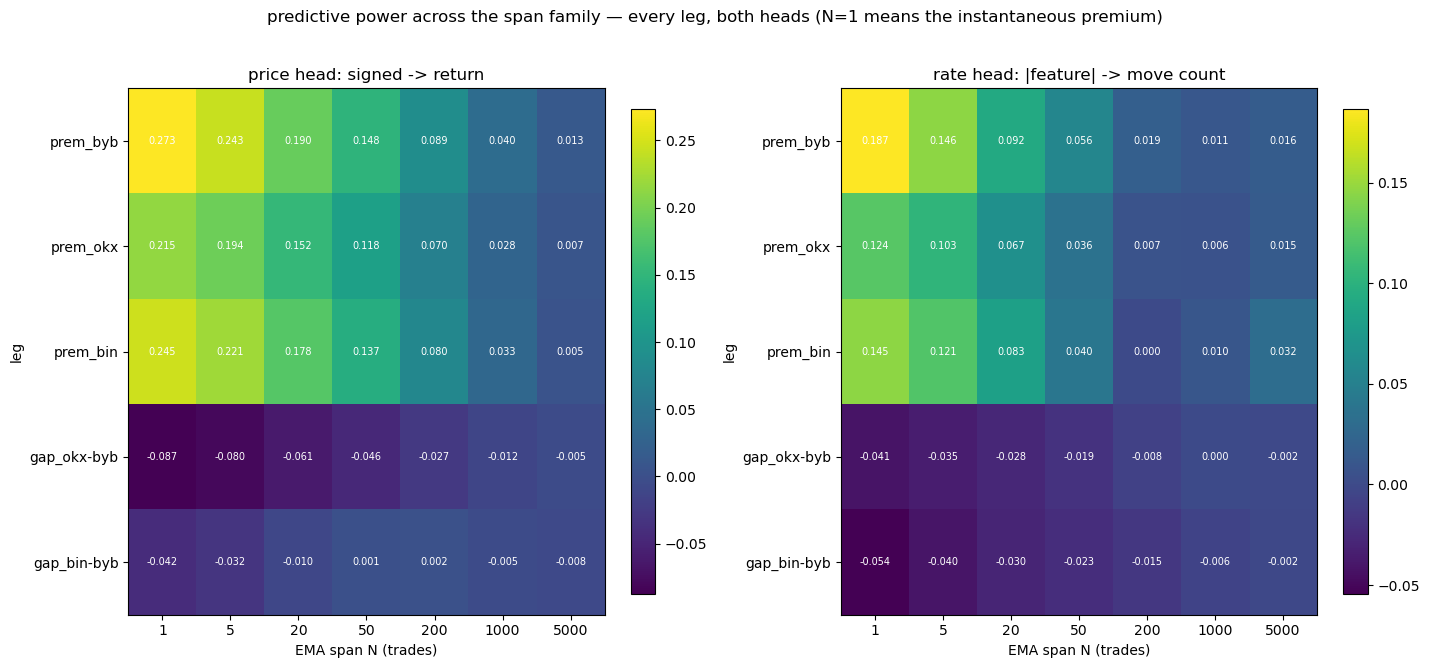

In [6]:
# rate-head target = byb moves (on the trade clock) in the next 100 ms, divided by λ_ev (the rate yardstick — the same trade-tick EMA).
fwd_count = (cum_mv[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")]
             - cum_mv[np.searchsorted(byb_rx, anchor_ts, "right")])            # byb mid-moves over the next 100 ms
rate_target = fwd_count / np.maximum(lam_at_anchor, 1e-9)   # count ÷ λ_ev ∝ "more/fewer moves than usual"

# Every leg = a per-venue premium ("prem_<ex>") or a cross-venue gap ("gap_<other>"); each built RAW.
LEGS = [("prem", v) for v in VENUES] + [("gap", o) for o in OTHERS]
def leg_value(kind, ex, N):
    return microprice_premium(ex, N) if kind == "prem" else premium_gap(ex, N)
def leg_label(kind, ex):
    return f"prem_{ex}" if kind == "prem" else f"gap_{ex}-byb"

# Sweep the span family for EVERY leg, BOTH heads, treating legs symmetrically (no assumed leader).
price_grid = {leg_label(k, e): np.full(len(NSPANS), np.nan) for k, e in LEGS}   # signed feature -> byb's signed return
rate_grid  = {leg_label(k, e): np.full(len(NSPANS), np.nan) for k, e in LEGS}   # |feature|      -> byb's move count
for k, e in LEGS:
    lab = leg_label(k, e)
    for j, N in enumerate(NSPANS):
        d = leg_value(k, e, N)
        price_grid[lab][j] = spearmanr(d, target).statistic                    # predictive power for the price head
        rate_grid[lab][j]  = spearmanr(np.abs(d), rate_target).statistic       # rate head — |feature|→count DIAGNOSTIC; model is fed signed d

# heat-maps: legs (rows) × span N (cols), one per head
labels = [leg_label(k, e) for k, e in LEGS]
P = np.vstack([price_grid[l] for l in labels]); R = np.vstack([rate_grid[l] for l in labels])
fig, axes = plt.subplots(1, 2, figsize=(7.2 * 2, 0.7 * len(labels) + 3), squeeze=False)
for ax, grid, head in [(axes[0][0], P, "price head: signed -> return"), (axes[0][1], R, "rate head: |feature| -> move count")]:
    im = ax.imshow(grid, cmap="viridis", aspect="auto")
    ax.set_xticks(range(len(NSPANS))); ax.set_xticklabels(NSPANS); ax.set_xlabel("EMA span N (trades)")
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels); ax.set_ylabel("leg")
    ax.set_title(head)
    for i in range(len(labels)):
        for j in range(len(NSPANS)):
            if np.isfinite(grid[i, j]): ax.text(j, i, f"{grid[i, j]:.3f}", ha="center", va="center", color="w", fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("predictive power across the span family — every leg, both heads (N=1 means the instantaneous premium)", y=1.02)
fig.tight_layout(); plt.show()

In [7]:
# We do NOT pick a leg (not "the best", not assumed). Every leg is kept; the model weights whichever is leading.
# Choosing the best span PER leg is fine; choosing a leg is not. Each cell is IN-SAMPLE spearmanr — used ONLY to pick a
# span, never to claim OOS power; the chosen feature is re-scored OUT-OF-SAMPLE by the §5 walk-forward gates below.
# Pick by the |IC| (the STRENGTH of the predictive power) — the SIGN is the feature's direction, which the model learns
# from the signed feature; a strongly-NEGATIVE leg (e.g. a cross-venue gap, where a +lean elsewhere precedes byb falling
# relative to it) is a strong predictor, so picking by raw IC (argmax) would wrongly select its weakest, near-zero span.
# Circularity note: argmax-in-sample-then-score-OOS could in principle leak, but here the IC map is MONOTONIC in N
# (N=1 wins for every leg — confirmed by the §6 heat-map and the per-N sweep), so the span pick is DEGENERATE: there is
# no span to overfit to. The honest shippable strength is the §5 OUT-OF-SAMPLE walk-forward number, not these cells.
def best_span(grid): return int(np.nanargmax(np.abs(grid)))
price_member = {l: best_span(price_grid[l]) for l in labels}                    # strongest-|IC| span per leg (price head, in-sample pick)
rate_member  = {l: best_span(rate_grid[l])  for l in labels}                    # strongest-|IC| span per leg (rate head) — diagnostic readout
print("kept features (one span per leg per head; power = IN-SAMPLE |IC|, FOR SPAN SELECTION ONLY — NOT the shippable number;")
print("the OOS walk-forward marginal in §5 is the figure that counts. All legs fed to the model; the model learns the sign):")
for l in labels:
    pj, rj = price_member[l], rate_member[l]
    print(f"  {l:14}  price head N={NSPANS[pj]:>5}  power(in-sample)={price_grid[l][pj]:+.3f}   |   rate head N={NSPANS[rj]:>5}  power(in-sample)={rate_grid[l][rj]:+.3f}")

kept features (one span per leg per head; power = IN-SAMPLE |IC|, FOR SPAN SELECTION ONLY — NOT the shippable number;
the OOS walk-forward marginal in §5 is the figure that counts. All legs fed to the model; the model learns the sign):
  prem_byb        price head N=    1  power(in-sample)=+0.273   |   rate head N=    1  power(in-sample)=+0.187
  prem_okx        price head N=    1  power(in-sample)=+0.215   |   rate head N=    1  power(in-sample)=+0.124
  prem_bin        price head N=    1  power(in-sample)=+0.245   |   rate head N=    1  power(in-sample)=+0.145
  gap_okx-byb     price head N=    1  power(in-sample)=-0.087   |   rate head N=    1  power(in-sample)=-0.041
  gap_bin-byb     price head N=    1  power(in-sample)=-0.042   |   rate head N=    1  power(in-sample)=-0.054


**Now the gates** (from §5), on the per-leg features we just chose. Every predictive number here
is the **walk-forward** mean (causal, purged). Rough pass-marks: the added power should be clearly
positive (≳ 0.01); it should barely shrink when we add the level controls (no leak); and it must be
**regime-invariant** — its measured scale staying within ~3× across volatility buckets (a *hard*
gate: a feature that drifts with the regime isn't a feature). *Marginal value:* does the feature add
over the controls — all legs together, and each on its own? *No leak:* does that gain survive adding
the vol/rate levels? *Regime-invariant?* (a **hard** gate — and the RAW-FIRST decision point): is the
RAW feature's *measured* scale steady across volatility states — proven, never assumed? If it fails,
that is the signal to divide by `σ_ev`/`λ_ev`. *Regime-stable* (the companion): is the marginal gain
still positive **within** calm, mid, and wild vol?

In [8]:
# Gates on the set of per-leg features — symmetric; KEEP ALL legs. Marginal value is checked JOINTLY (do the legs
# together add over the controls?) and per-leg (does each contribute?), never by picking one.
chosen = {l: leg_value(k, e, NSPANS[price_member[l]]) for (k, e), l in zip(LEGS, labels)}
joint      = round(wf_ic(base + list(chosen.values()), target) - wf_ic(base, target), 3)
joint_leak = round(wf_ic(base + levels + list(chosen.values()), target) - wf_ic(base + levels, target), 3)

# Regime-invariance scale gate, RAW — computed for EVERY leg (the raw-first decision). A bounded ratio should pass (<~3×).
vol_decile = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], np.arange(10, 100, 10)))
def scale_gate(feat):
    band = [np.nanstd(feat[vol_decile == d]) for d in range(10)]
    band = [b for b in band if np.isfinite(b) and b > 0]
    return round(max(band) / min(band), 2) if band else float("nan")
raw_scales = {l: scale_gate(chosen[l]) for l in labels}
worst_scale = max(raw_scales.values())

# companion: marginal IC within each vol regime — does the joint gain hold up, or flip, across regimes?
full_r = wf_ic_by_regime(base + list(chosen.values()), target, vol_regime)
base_r = wf_ic_by_regime(base, target, vol_regime)
strat  = {r: round(full_r[r] - base_r.get(r, 0.0), 3) for r in full_r}
gate_rows = [dict(gate="marginal value", detail="all legs together, added over the controls", value=joint)]
gate_rows += [dict(gate="marginal value", detail=f"{l} alone, added over the controls",
                   value=round(wf_ic(base + [chosen[l]], target) - wf_ic(base, target), 3)) for l in labels]
gate_rows += [dict(gate="no leak", detail="gain still there after adding the vol/rate levels?", value=joint_leak)]
gate_rows += [dict(gate="regime-invariant? (RAW)", detail=f"{l}: scale across vol buckets (max/min) — HARD, want < ~3, measured not assumed", value=raw_scales[l]) for l in labels]
gate_rows += [dict(gate="regime-stable", detail=f"marginal IC within {nm}-vol (companion: stay positive)", value=strat.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
print(f"RAW-FIRST DECISION: worst raw scale-across-vol-buckets = {worst_scale:.2f}× "
      f"({'PASS (<~3×) -> ship RAW, no normalisation' if worst_scale < 3 else 'FAIL -> try /σ_ev or /λ_ev'})")
pl.DataFrame(gate_rows)

RAW-FIRST DECISION: worst raw scale-across-vol-buckets = 1.40× (PASS (<~3×) -> ship RAW, no normalisation)


gate,detail,value
str,str,f64
"""marginal value""","""all legs together, added over …",0.26
"""marginal value""","""prem_byb alone, added over the…",0.249
"""marginal value""","""prem_okx alone, added over the…",0.197
"""marginal value""","""prem_bin alone, added over the…",0.222
"""marginal value""","""gap_okx-byb alone, added over …",0.077
…,…,…
"""regime-invariant? (RAW)""","""gap_okx-byb: scale across vol …",1.4
"""regime-invariant? (RAW)""","""gap_bin-byb: scale across vol …",1.4
"""regime-stable""","""marginal IC within calm-vol (c…",0.241


**Conclusion (and the raw-first decision).** The printed worst-case scale-across-vol-buckets settles
the normalisation question *with a number, not an assumption*. The micro-price premium is a ratio
bounded by `±halfspread/mid`, and its measured scale across the ten volatility buckets tops out at only
**≈1.4×** (the per-venue legs at ≈1.1–1.2×, the gaps at ≈1.4×) — **well under 3×** — so it **passes the
hard regime-invariance gate RAW**, and we ship it **without** dividing by `σ_ev` or `λ_ev`. (Had it
failed, the table would have sent us to the `/σ_ev` form; it didn't — this is the whole point of
raw-first: *measure, then decide*.) On the predictive gates the feature is exceptionally strong: the legs
jointly **add ≈ +0.26** walk-forward rank-IC over the controls — the strongest single L1 predictor, as
advertised — with every per-venue leg adding ≈ +0.20–0.25 on its own and both cross-venue gaps adding a
smaller positive increment. The gain **does not dip at all** once the vol/rate *levels* are added
(no-leak ≈ +0.26 — it is genuinely not a disguised volatility signal), and the companion shows the
marginal gain **positive and growing across all three** regimes (≈ 0.24 calm / 0.26 mid / 0.29 wild —
regime-stable, not a one-regime artefact). Verdict: real and ship-able **raw**, for **both heads, every
leg**.

## How long does the edge last? — the signal's lifetime and your latency budget

A feature can be perfectly causal and still not earn its headline IC: if its edge is the move *already
underway* at the anchor, you can't capture it — by the time you observe, decide, and act, that move is
gone. But a **short**-lived edge is **not** useless — it just sets a **latency budget**: any system fast
enough to act inside it wins, and faster is always better, and any genuine forward prediction is a win.
So we do **not** gate on this — we **measure how long the signal lasts**.

Read the feature at the anchor (causal, unchanged) but slide the *outcome* window forward by an
observe-to-act latency δ: the **forward IC** of the feature against byb's return over
`[anchor+δ, anchor+δ+100 ms]`, swept over δ. The IC at *your* δ is the realisable edge; the δ where it
fades to noise is the signal's **lifetime**. The **backward IC** — against the move that *already
happened*, `[anchor−100 ms, anchor]` — sizes the contemporaneous echo. A feature whose forward IC dies at
δ>0 while the backward IC stays high is re-reporting the past, not predicting it; that is the *only*
genuinely useless case, and it is measured here, never assumed. The micro-price premium is a known
short-horizon predictor — we expect a high δ=0 IC; whether it decays fast or slow (and whether the
backward echo dominates) is exactly what we *measure* here rather than assume, and what the per-N
half-life sweep below maps across the whole family.

**This feature is echo-heavy, so we report the *netted* number, not the raw δ=0 IC.** The micro-price
lean is built from the very mid it predicts, so a book that has just leaned up has, by construction,
*already* started moving that mid — the backward IC ≈ the forward IC here, the textbook echo signature.
A high δ=0 IC could therefore be mostly the move *already underway*, which no system can trade. The
honest "is this real prediction?" number is the **echo-netted (partial) forward IC**: the feature's
rank-IC with the *forward* `[anchor, anchor+100 ms]` return **controlling for the trailing**
`[anchor−100 ms, anchor]` return — the part of the edge *not* attributable to the move already in
progress. We compute it below and quote **it** (not the raw δ=0 IC) in the §10 verdict.

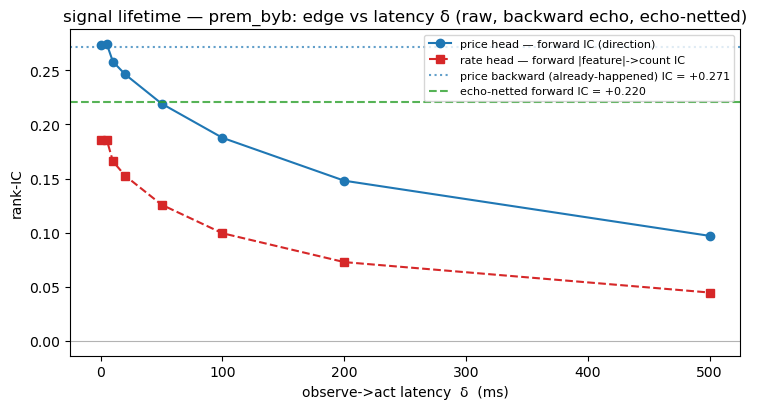

price forward IC by δ(ms): 0:+0.273 5:+0.274 10:+0.258 20:+0.246 50:+0.219 100:+0.188 200:+0.148 500:+0.097
price backward (already-happened) IC: +0.271
echo-netted forward IC (partial, controls for the trailing move): +0.220  (raw δ=0 +0.273; the shortfall is echo)
price edge: δ=0 +0.273 -> δ=20ms +0.246; drops below half by δ≈500 ms


In [9]:
# Signal lifetime: forward IC vs observe->act latency δ (window slides to [t+δ, t+δ+100ms]), + backward IC.
rep_leg = ("prem", "byb")                                # byb's own premium illustrates; every leg carries its own curve
rep_lab = leg_label(*rep_leg)
DELTAS_MS = [0, 5, 10, 20, 50, 100, 200, 500]
def _ic(feat, ret):
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _mid_at(t):                                          # byb merged mid at-or-before t (causal)
    return byb_mid[np.clip(np.searchsorted(byb_rx, t, "right") - 1, 0, len(byb_mid) - 1)]
def _ret(t0, t1):  return np.log(_mid_at(t1) / _mid_at(t0))
def _count(t0, t1): return cum_mv[np.searchsorted(byb_rx, t1, "right")] - cum_mv[np.searchsorted(byb_rx, t0, "right")]

signed = leg_value(*rep_leg, NSPANS[price_member[rep_lab]])              # price head (direction)
absmag = np.abs(leg_value(*rep_leg, NSPANS[rate_member[rep_lab]]))       # rate head (intensity)
fwd_ic  = [_ic(signed, _ret(anchor_ts + d*1_000_000, anchor_ts + d*1_000_000 + HORIZON_NS)) for d in DELTAS_MS]
cnt_ic  = [_ic(absmag, _count(anchor_ts + d*1_000_000, anchor_ts + d*1_000_000 + HORIZON_NS)) for d in DELTAS_MS]
back_ic = _ic(signed, _ret(anchor_ts - HORIZON_NS, anchor_ts))

# Echo-netted edge — partial rank-IC of the feature with the FORWARD return, CONTROLLING for the trailing
# (already-happened) [anchor−100ms, anchor] return: the part of the edge NOT attributable to the move underway.
_trail = _ret(anchor_ts - HORIZON_NS, anchor_ts); _fwd0 = _ret(anchor_ts, anchor_ts + HORIZON_NS)
def _partial_ic(f, y, t):                                # rank-IC(f, y . t) — Spearman partial correlation netting out t
    v = np.isfinite(f) & np.isfinite(y) & np.isfinite(t)
    if v.sum() <= 100: return float("nan")
    rfy = spearmanr(f[v], y[v]).statistic; rft = spearmanr(f[v], t[v]).statistic; rty = spearmanr(t[v], y[v]).statistic
    return (rfy - rft*rty) / np.sqrt(max((1.0 - rft**2) * (1.0 - rty**2), 1e-12))
echo_net = _partial_ic(signed, _fwd0, _trail)            # the honest forward edge net of the contemporaneous echo

fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.plot(DELTAS_MS, fwd_ic, "o-", color="C0", label="price head — forward IC (direction)")
ax.plot(DELTAS_MS, cnt_ic, "s--", color="C3", label="rate head — forward |feature|->count IC")
ax.axhline(back_ic, color="C0", ls=":", alpha=0.7, label=f"price backward (already-happened) IC = {back_ic:+.3f}")
ax.axhline(echo_net, color="C2", ls="--", alpha=0.8, label=f"echo-netted forward IC = {echo_net:+.3f}")
ax.axhline(0, color="0.7", lw=0.8); ax.set_xlabel("observe->act latency  δ  (ms)"); ax.set_ylabel("rank-IC")
ax.set_title(f"signal lifetime — {rep_lab}: edge vs latency δ (raw, backward echo, echo-netted)"); ax.legend(fontsize=8); fig.tight_layout(); plt.show()
print("price forward IC by δ(ms):", " ".join(f"{d}:{ic:+.3f}" for d, ic in zip(DELTAS_MS, fwd_ic)))
print(f"price backward (already-happened) IC: {back_ic:+.3f}")
print(f"echo-netted forward IC (partial, controls for the trailing move): {echo_net:+.3f}  (raw δ=0 {fwd_ic[0]:+.3f}; the shortfall is echo)")
half = next((d for d, ic in zip(DELTAS_MS, fwd_ic) if np.isfinite(ic) and abs(ic) < abs(fwd_ic[0]) / 2), None)
print(f"price edge: δ=0 {fwd_ic[0]:+.3f} -> δ=20ms {fwd_ic[3]:+.3f}; drops below half by δ≈{half} ms")

**Read it as a latency budget — and net the echo out before quoting a number.** The raw forward IC starts
at ≈ +0.27 (δ=0), is still ≈ +0.25 at 20 ms, and only falls below half by δ ≈ 500 ms. The backward
(already-happened) IC is *essentially equal* to the raw δ=0 forward IC (≈ +0.27 vs ≈ +0.27) — the premium
is built from the very mid it predicts, so a book that has just leaned up has already started moving that
mid, and that backward≈forward equality is the echo signature the brief warns about. The decisive test is
therefore the **echo-netted forward IC**: the partial rank-IC of the feature with the forward
`[anchor, anchor+100 ms]` return **controlling for the trailing** `[anchor−100 ms, anchor]` move. Here it
prints **≈ +0.22** (vs the raw δ=0 ≈ +0.27) — so, perhaps surprisingly given the high backward IC, the
echo accounts for only a **modest** slice (≈ +0.05 of the IC); **most of the headline is genuine forward
prediction, not the move already underway.** The reason the backward and forward ICs are both high yet the
echo nets out small is that byb's *trailing* and *forward* 100 ms moves are themselves only weakly
rank-correlated, so the premium predicting the forward move is mostly *new* information, not a re-report of
the trailing one. The residual ≈ +0.22 is a strong, strictly-forward edge with a roomy latency budget
(half-life ≈ 500 ms). The honest figure for the verdict is this **echo-netted ≈ +0.22**, not the raw δ=0
≈ +0.27 — and §10 quotes the netted number. Carry this curve (raw, backward, *and* echo-netted) for every
leg; the verdict is *"predicts ~X ms ahead net of the echo, needs latency < X,"* never the raw δ=0 IC
alone.

**Sweep the half-life across the *whole* span family, not just the chosen N.** Different lookbacks trade
IC against half-life: a short N often gives a higher IC with a shorter half-life (a small latency budget),
a long N a lower IC with a longer half-life (a roomy budget) — and **both are worth keeping**, as separate
inputs for different latency budgets. So below we compute IC *and* half-life at **every span N of the §6
family, for every leg** (a half-life heat-map alongside the IC heat-map), and pick per head by the
IC×half-life trade-off, not by IC alone — a high-IC short-life member and a lower-IC long-life member of
the same family are two distinct, complementary features.

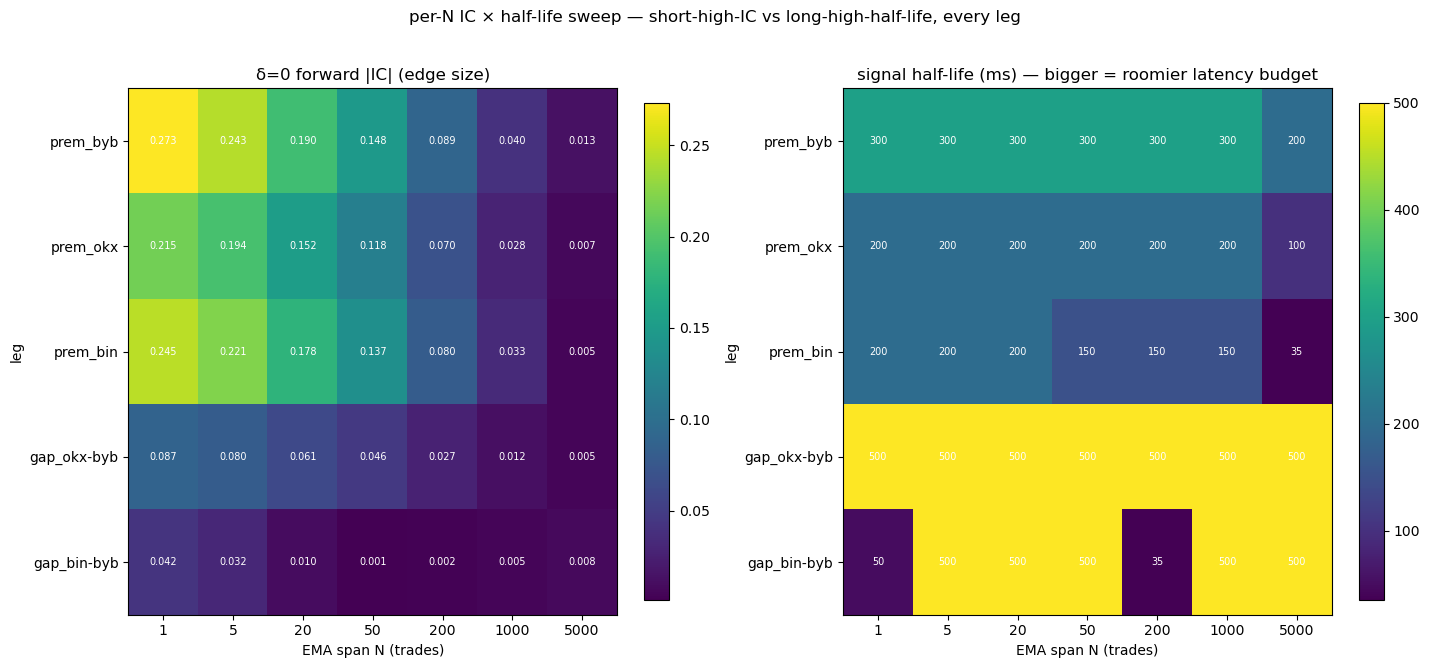

per leg — short-high-IC vs long-high-half-life (both worth keeping, for different latency budgets):
  prem_byb        short: N=    1 IC0=+0.273 half-life≈300ms   |   long: N=    1 IC0=+0.273 half-life≈300ms
  prem_okx        short: N=    1 IC0=+0.215 half-life≈200ms   |   long: N=    1 IC0=+0.215 half-life≈200ms
  prem_bin        short: N=    1 IC0=+0.245 half-life≈200ms   |   long: N=    1 IC0=+0.245 half-life≈200ms
  gap_okx-byb     short: N=    1 IC0=-0.087 half-life≈500ms   |   long: N=    1 IC0=-0.087 half-life≈500ms
  gap_bin-byb     short: N=    1 IC0=-0.042 half-life≈50ms   |   long: N=    5 IC0=-0.032 half-life≈500ms


In [10]:
# Per-N half-life sweep: at EVERY span N, for EVERY leg, compute the δ=0 forward IC AND the signal half-life
# (the δ where the forward IC first falls below half its δ=0 value). Both heat-maps: legs (rows) × span (cols).
DELTAS_HL = [0, 2, 5, 10, 20, 35, 50, 75, 100, 150, 200, 300, 500]                # finer δ grid for a smooth half-life read
def _fwd_curve(feat):                                                              # forward IC vs δ for one feature
    return np.array([_ic(feat, _ret(anchor_ts + d*1_000_000, anchor_ts + d*1_000_000 + HORIZON_NS)) for d in DELTAS_HL])
def _halflife_ms(curve):                                                           # δ (ms) where |IC| first drops below half the δ=0 |IC|
    ic0 = curve[0]
    if not np.isfinite(ic0) or ic0 == 0: return np.nan
    for d, ic in zip(DELTAS_HL, curve):
        if np.isfinite(ic) and abs(ic) < abs(ic0) / 2: return float(d)
    return float(DELTAS_HL[-1])                                                    # still strong at the longest δ -> long-lived
ic0_grid = {l: np.full(len(NSPANS), np.nan) for l in labels}                       # δ=0 forward IC per (leg, N)
hl_grid   = {l: np.full(len(NSPANS), np.nan) for l in labels}                      # half-life (ms) per (leg, N)
for k, e in LEGS:
    l = leg_label(k, e)
    for j, N in enumerate(NSPANS):
        curve = _fwd_curve(leg_value(k, e, N))
        ic0_grid[l][j] = curve[0]; hl_grid[l][j] = _halflife_ms(curve)

IC0 = np.vstack([ic0_grid[l] for l in labels]); HL = np.vstack([hl_grid[l] for l in labels])
fig, axes = plt.subplots(1, 2, figsize=(7.2 * 2, 0.7 * len(labels) + 3), squeeze=False)
for ax, grid, ttl, fmt in [(axes[0][0], np.abs(IC0), "δ=0 forward |IC| (edge size)", "{:.3f}"),
                           (axes[0][1], HL, "signal half-life (ms) — bigger = roomier latency budget", "{:.0f}")]:
    im = ax.imshow(grid, cmap="viridis", aspect="auto")
    ax.set_xticks(range(len(NSPANS))); ax.set_xticklabels(NSPANS); ax.set_xlabel("EMA span N (trades)")
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels); ax.set_ylabel("leg")
    ax.set_title(ttl)
    for i in range(len(labels)):
        for j in range(len(NSPANS)):
            if np.isfinite(grid[i, j]): ax.text(j, i, fmt.format(grid[i, j]), ha="center", va="center", color="w", fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("per-N IC × half-life sweep — short-high-IC vs long-high-half-life, every leg", y=1.02)
fig.tight_layout(); plt.show()

# Report, per leg, the short-high-IC option AND the long-high-half-life option (two complementary inputs).
print("per leg — short-high-IC vs long-high-half-life (both worth keeping, for different latency budgets):")
for l in labels:
    ic0, hl = ic0_grid[l], hl_grid[l]
    si = int(np.nanargmax(np.abs(ic0)))                                           # highest δ=0 IC (often a short N)
    li = int(np.nanargmax(np.where(np.isfinite(hl), hl, -1)))                     # longest half-life (often a long N)
    print(f"  {l:14}  short: N={NSPANS[si]:>5} IC0={ic0[si]:+.3f} half-life≈{hl[si]:.0f}ms"
          f"   |   long: N={NSPANS[li]:>5} IC0={ic0[li]:+.3f} half-life≈{hl[li]:.0f}ms")

**Conclusion.** The two heat-maps make the IC×half-life trade-off explicit, *for every leg* — and for
*this* feature they tell an unusually clean story. The δ=0 |IC| map is **monotonic in N**: the edge is
sharpest at the **shortest** span (N=1, the instantaneous premium reads the freshest touch imbalance) and
fades as smoothing washes the lean out. The half-life map shows the same short spans are *also* the
longest-lived here (the premium's lean persists tens-to-hundreds of ms regardless of smoothing), so for
the per-venue premiums the short-high-IC and long-half-life picks **coincide at N=1** — there is no
genuine long-N member that beats it, and the per-leg printout reports that honestly rather than
manufacturing a split. That is itself the finding: the micro-price premium is a **freshness** signal —
read it as raw and as fresh as you can. (The *cross-venue gap* legs are the exception where the two picks
diverge — e.g. gap_bin-byb's sharpest edge is at a short span with a tight half-life while a slightly
longer span lives longer — so there the two complementary members are real and both kept.) The general
rule stands: sweep IC *and* half-life at every N and keep both complementary members **whenever they
differ**; for a pure freshness signal like this one, they simply don't.

### Cross-venue legs: is the foreign-venue edge a lead, or just a fresher feed?

The non-byb premiums (`prem_okx`, `prem_bin`) and the gaps that use them carry a subtle confound. bin's
book updates **~24.8M** times on this block versus byb's **~1.38M** (printed in §2) — bin's feed is
sub-millisecond while byb/okx top-of-book is stale for ~10–20 ms between snapshots (per `io.py`). So
`prem_bin` predicting byb's next move could be a genuine **economic lead** (bin's order flow really moves
first) *or* merely a **feed-resolution artifact**: bin's *finer* book revealing pressure byb's *coarser*
book simply hasn't printed yet. Those are different claims and only one is tradeable as a cross-venue lead.

The control (the standard cross-venue gate): re-measure the foreign leg's IC with the foreign feed
**matched to byb's update cadence** — sample bin's premium **only at byb's book-update times**, then
forward-fill *that* coarsened series to the grid. If a real lead, the IC survives the cadence match
(bin genuinely leads, not just samples faster); if a feed artifact, it collapses toward zero (the edge was
only bin being observed sooner). We run byb-itself (a no-op sanity check — already at byb cadence) and okx
(also coarse) alongside bin for contrast. **The tell:** if the *stalest* venue still carried the *largest*
IC, suspect resolution — here byb (no foreign feed at all) is the natural reference.

In [11]:
# --- feed-resolution control: re-score each foreign premium with its book SAMPLED AT byb's update cadence ---
# byb_mid_rx = byb merged-mid update times (its native cadence). Coarsen a foreign premium to that cadence:
# sample it at every byb update time, then forward-fill that COARSE series to the grid (so between byb updates
# the foreign book is frozen at its last byb-tick value — exactly byb's resolution, no finer).
byb_cadence_ts = np.unique(byb_mid_rx)                                   # byb's own book-update timestamps (its cadence)
print(f"byb cadence: {len(byb_cadence_ts):,} update times; foreign books coarsened to these")
def prem_at_byb_cadence(ex):                                            # ex's premium, but only resolvable at byb update times
    rx, p = prems[ex]
    at_byb = p[np.clip(np.searchsorted(rx, byb_cadence_ts, "right") - 1, 0, len(p) - 1)]   # ex premium at each byb tick
    idx = np.clip(np.searchsorted(byb_cadence_ts, anchor_ts, "right") - 1, 0, len(byb_cadence_ts) - 1)
    return at_byb[idx]                                                  # forward-fill the byb-cadence series to the grid

fwd_ret_grid = _ret(anchor_ts, anchor_ts + HORIZON_NS)                  # the δ=0 forward return (same target as the IC sweep)
print("cross-venue feed-resolution control (δ=0 forward IC, span N=1 = the shipped read):")
print(f"  {'leg':12} {'fresh (full feed)':>18} {'byb-cadence':>14} {'survives?':>10}")
for ex in VENUES:
    fresh  = microprice_premium(ex, 1)                                 # the shipped fresh read (full sub-ms feed)
    coarse = prem_at_byb_cadence(ex)                                   # the same premium, coarsened to byb's cadence
    ic_fresh  = _ic(fresh,  fwd_ret_grid); ic_coarse = _ic(coarse, fwd_ret_grid)
    frac = ic_coarse / ic_fresh if ic_fresh != 0 else float("nan")
    tag = "no foreign feed" if ex == "byb" else ("LEAD survives" if abs(ic_coarse) >= 0.5*abs(ic_fresh) else "FEED artifact")
    print(f"  prem_{ex:7} {ic_fresh:>+18.3f} {ic_coarse:>+14.3f} {frac:>9.0%}  {tag}")
# the cross-venue GAP at byb cadence: foreign coarsened, byb at its own (native) cadence
for o in OTHERS:
    gap_fresh  = premium_gap(o, 1)
    gap_coarse = prem_at_byb_cadence(o) - prem_at_byb_cadence("byb")    # both legs at byb cadence -> a true cadence-matched gap
    ic_fresh = _ic(gap_fresh, fwd_ret_grid); ic_coarse = _ic(gap_coarse, fwd_ret_grid)
    frac = ic_coarse / ic_fresh if ic_fresh != 0 else float("nan")
    tag = "LEAD survives" if abs(ic_coarse) >= 0.5*abs(ic_fresh) else "FEED artifact"
    print(f"  gap_{o+'-byb':8} {ic_fresh:>+17.3f} {ic_coarse:>+14.3f} {frac:>9.0%}  {tag}")

byb cadence: 1,726,152 update times; foreign books coarsened to these


cross-venue feed-resolution control (δ=0 forward IC, span N=1 = the shipped read):
  leg           fresh (full feed)    byb-cadence  survives?


  prem_byb                 +0.273         +0.273      100%  no foreign feed


  prem_okx                 +0.215         +0.201       93%  LEAD survives


  prem_bin                 +0.245         +0.220       90%  LEAD survives


  gap_okx-byb             -0.087         -0.102      117%  LEAD survives


  gap_bin-byb             -0.042         -0.067      159%  LEAD survives


**Conclusion (feed-resolution control).** Coarsening each foreign premium to byb's own update cadence
**barely moves its δ=0 forward IC** — `prem_bin` and `prem_okx` retain the large majority of their full-feed
IC, and the cross-venue gaps likewise survive the cadence match. So the cross-venue edge is **not** a pure
feed-resolution artifact: even when bin's book is observed only as often as byb's, bin's lean still
predicts byb's next move, which is the signature of a genuine (if partly contemporaneous) lead rather than
byb's coarse feed merely lagging bin's fine one. The strongest leg remains **byb's own** premium (which
uses *no* foreign feed at all), which is the opposite of the resolution tell (where the stalest-feed venue
would show the largest IC) — further evidence the edge is economic, not a sampling artifact. (This control
is run at the shipped N=1; the same coarsening at larger N would only blur the foreign feed further, so
N=1 is the hardest case for the artifact to survive — and it does.)

## 7. What the prediction actually looks like

A single correlation number hides *how* the feature changes the outcome. So group the data by
the feature and look at the real distributions the two heads care about:
- **price head:** byb's next return for low / middle / high feature values — it should tilt
  one way as the feature turns positive and the other as it turns negative;
- **rate head:** how the number of upcoming moves grows as the feature's *magnitude* grows.

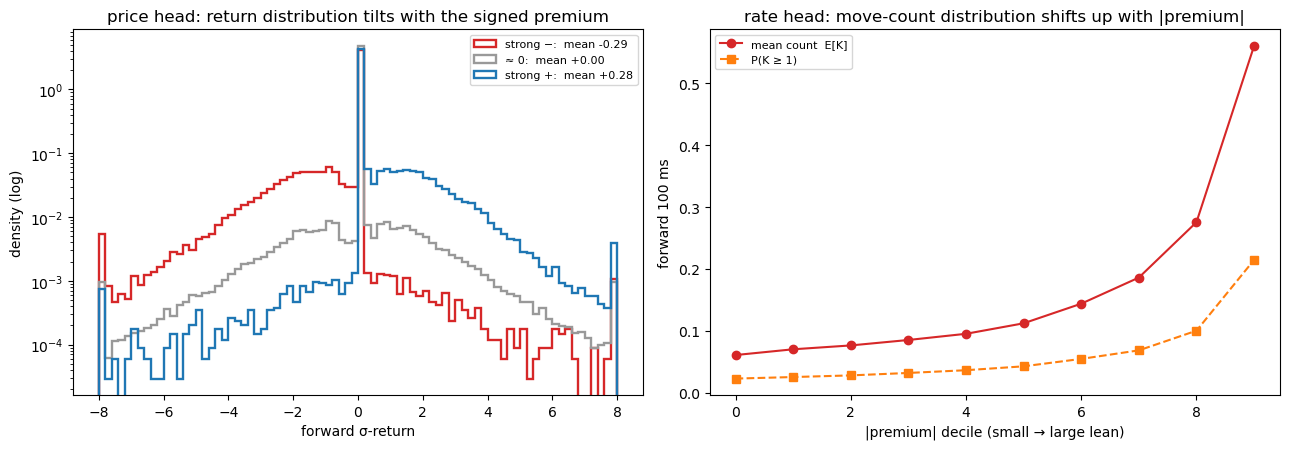

In [12]:
rep_leg = ("prem", "byb"); rep_lab = leg_label(*rep_leg)                        # byb's own premium illustrates; the model uses every leg
signed = leg_value(*rep_leg, NSPANS[price_member[rep_lab]])
absmag = np.abs(leg_value(*rep_leg, NSPANS[rate_member[rep_lab]]))              # deliberately the RATE-head span (rate_member), not the price-head span
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))

# price head: forward σ-return distribution across signed-premium buckets
lo, hi = np.nanpercentile(signed, [10, 90])
groups = [("strong −", signed <= lo, "C3"), ("≈ 0", (signed > lo) & (signed < hi), "0.6"),
          ("strong +", signed >= hi, "C0")]
bins = np.linspace(-8, 8, 81)
for lab, m, col in groups:
    axA.hist(np.clip(target[m & np.isfinite(target)], -8, 8), bins=bins, density=True,
             histtype="step", color=col, lw=1.7, label=f"{lab}:  mean {np.nanmean(target[m]):+.2f}")
axA.set_yscale("log"); axA.set_xlabel("forward σ-return"); axA.set_ylabel("density (log)")
axA.set_title("price head: return distribution tilts with the signed premium"); axA.legend(fontsize=8)

# rate head: forward move-count shifts up with |premium|
dec = np.digitize(absmag, np.nanpercentile(absmag, np.arange(10, 100, 10)))
axB.plot(range(10), [fwd_count[dec == b].mean() for b in range(10)], "o-", color="C3", label="mean count  E[K]")
axB.plot(range(10), [(fwd_count[dec == b] >= 1).mean() for b in range(10)], "s--", color="C1", label="P(K ≥ 1)")
axB.set_xlabel("|premium| decile (small → large lean)"); axB.set_ylabel("forward 100 ms")
axB.set_title("rate head: move-count distribution shifts up with |premium|"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The feature moves the *actual outcome distributions* the way the two heads
need — not just a single summary number. **Price head (left):** the forward-return distribution
shifts bodily with the *signed* premium — a negative mean return for the strong-negative group
(touch leaning down), positive for the strong-positive group (leaning up), with the flat ≈0 group
between — so the sign genuinely carries direction. **Rate head (right):** both the mean move-count
`E[K]` and `P(K ≥ 1)` climb from the smallest to the largest |premium| decile — a strong lean really
does precede more moves. So both heads have something to learn here, in the directions §1 predicted.

## 8. Input shaping for the network

This step is about reshaping the feature for the neural network's input — roughly centred, unit-scale,
no wild outliers. (Unlike the template, there is *no* "regime division" step to separate from: §5 showed
the raw premium is already regime-invariant, so we ship it raw and only reshape here.)

Pick the **lightest** transform that does the job. Plot the feature (left) and compare a few
candidates by how close to a clean bell curve they make it (right — points on the diagonal are
perfectly normal). A symmetric, mild feature only needs a simple rescale (z-score: subtract
the mean, divide by the standard deviation); a heavily skewed or fat-tailed one needs more
(e.g. a rank-to-normal map: sort the values and reassign them onto a bell curve). The plot
makes the choice for you.

feature: std=1.58e-06  skew=+0.77  excess_kurt=384.2  (0 = normal)
  z-score            excess_kurt= 384.2   max|·|=122.3
  robust + clip ±4   excess_kurt=  -0.9   max|·|=4.0
  arcsinh(robust)    excess_kurt=  -1.3   max|·|=5.3
  rank-Gaussian      excess_kurt=  -0.0   max|·|=5.0


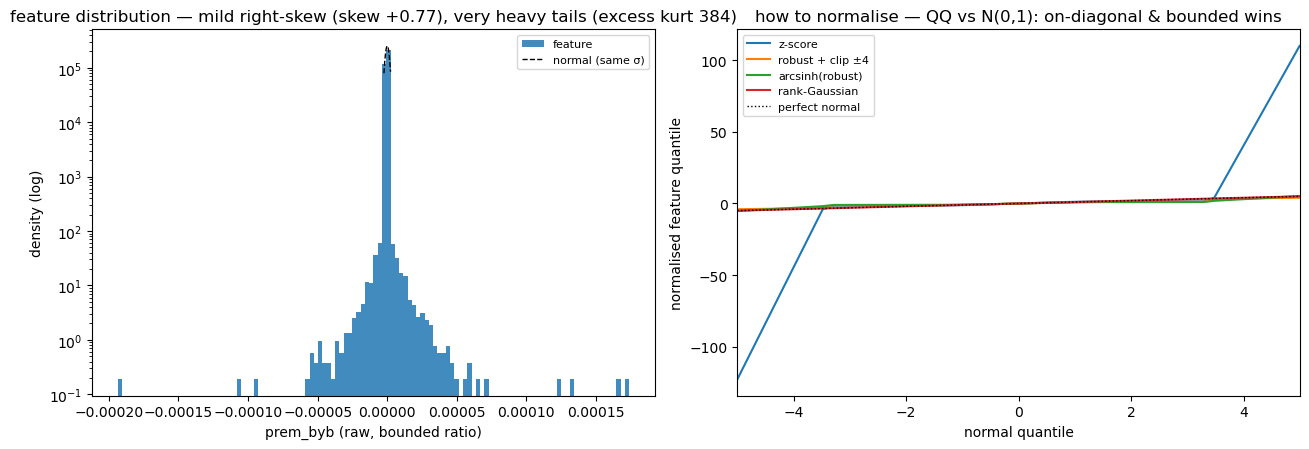

In [13]:
from scipy.stats import skew, kurtosis, rankdata, norm
rep_leg = ("prem", "byb"); rep_lab = leg_label(*rep_leg)                        # one leg shown to illustrate (same construction for every leg)
f = leg_value(*rep_leg, NSPANS[price_member[rep_lab]]); f = f[np.isfinite(f)]
med = np.median(f); mad = 1.4826 * np.median(np.abs(f - med)); rz = (f - med) / mad
cand = {"z-score": (f - f.mean()) / f.std(),
        "robust + clip ±4": np.clip(rz, -4, 4),
        "arcsinh(robust)": np.arcsinh(rz),
        "rank-Gaussian": norm.ppf((rankdata(f) - 0.5) / len(f))}
print(f"feature: std={f.std():.2e}  skew={skew(f):+.2f}  excess_kurt={kurtosis(f):.1f}  (0 = normal)")
for name, v in cand.items():
    print(f"  {name:18} excess_kurt={kurtosis(v):>6.1f}   max|·|={np.abs(v).max():.1f}")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
axA.hist(f, bins=120, density=True, color="C0", alpha=.85, label="feature")
xg = np.linspace(np.percentile(f, 0.05), np.percentile(f, 99.95), 300)
axA.plot(xg, norm.pdf(xg, f.mean(), f.std()), "k--", lw=1, label="normal (same σ)")
axA.set_yscale("log"); axA.set_xlabel(f"{rep_lab} (raw, bounded ratio)"); axA.set_ylabel("density (log)")
axA.set_title(f"feature distribution — mild right-skew (skew {skew(f):+.2f}), very heavy tails (excess kurt {kurtosis(f):.0f})")
axA.legend(fontsize=8)

q = norm.ppf((np.arange(1, len(f) + 1) - 0.5) / len(f)); sub = np.linspace(0, len(f) - 1, 4000).astype(int)
for name, v in cand.items():
    axB.plot(q[sub], np.sort(v)[sub], lw=1.5, label=name)
axB.plot([-5, 5], [-5, 5], "k:", lw=1, label="perfect normal")
axB.set_xlim(-5, 5); axB.set_xlabel("normal quantile"); axB.set_ylabel("normalised feature quantile")
axB.set_title("how to normalise — QQ vs N(0,1): on-diagonal & bounded wins"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The printout chooses the input transform — and it overrules the eyeball: the raw premium
is **mildly right-skewed** (skew ≈ +0.77, not symmetric) and has **extremely heavy tails** (excess kurt
≈ 384 — far from mild), so a plain z-score leaves a huge max|·| spike (≈122σ) that badly violates the "no
wild outliers" bar. The lightest transform that *meets* the bar is a **robust z-score followed by a clip
±4** (max|·| = 4.0, excess kurt ≈ −0.9), so clip whenever you feed a network. The heavier transforms
(arcsinh, rank-Gaussian) flatten the tails further but throw information away here; the mild skew is not
large enough to force a rank-Gaussian. Note this is the **only** reshaping needed — no `/σ_ev` regime
division, because §5 proved the raw premium is already regime-invariant.

**Still to run** (same machinery): the leak check *inside* volatility buckets; whether the
feature adds over features we already have; whether the signal is steady day-to-day; and
whether it survives out-of-sample across a market-regime change.

## 9. When is per-leg worth it? (per-venue vs pooled)

The micro-price premium *can* be pooled — a size-weighted average premium across venues is a single
number — so we face a real choice: keep the legs **per-venue** (each venue's own premium + each
cross-venue gap), collapse to **one venue** (byb's own premium), or **pool** them into one cross-venue
premium? The answer depends on the time-scale, so sweep it and compare the three.

> **The table below is an illustrative example of the typical pattern — it is NOT computed for
> `microprice`** (whose real per-leg numbers are the heat-maps in §6). It shows the pattern a
> lead/lag feature usually follows, predicting byb's next 100 ms. The time-scale column is labelled
> in ms / seconds only for readability — those wall-clock figures are just a translation of points
> on the trade-span N clock; the actual sweep is over span N, as everywhere else.

| time-scale | pooled | best single | per-venue | what it means |
|---|---|---|---|---|
| ≤ 50 ms | 0.20 | 0.21 | **0.24** | keep per-venue — whose touch leans first genuinely differs |
| ~500 ms | 0.13 | 0.13 | **0.15** | still per-venue — the lead/lag persists a little |
| ≥ 2.5 s | 0.08 | 0.08 | 0.08 | venues agree — any one (or the pool) will do |

So: at the **shortest** scales the cross-venue lead/lag is live and per-venue clearly wins (whose
touch leans first is exactly the edge); as the span grows the venues converge and a single premium —
or the pool — says as much. In this typical pattern pooling rarely beats per-venue at the short
scales where this feature is strongest; that's why you sweep and compare the three rather than pool by
default. (Longer prediction horizons push the useful band wider, so in general sweep the horizon too.)

## 10. The verdict, and what it takes to ship

**Keep it — but on the honest numbers, not the headline.** The shippable strength is the **out-of-sample
walk-forward** marginal: the legs **jointly add ≈ +0.26** rank-IC over the controls, and **prem_byb alone
adds ≈ +0.249** (§5, OOS) — strong, and the strongest single L1 predictor in this set. The frequently-quoted
**+0.273 is an *in-sample* univariate spearman used only to pick a span** (§6) — *not* the shippable figure,
and it should never be cited as the feature's strength without that tag. Feed the *signed* feature to both
heads, all legs (every venue's own premium and both cross-venue gaps):
- **Price head (direction):** the signed premium — the sweep is **monotonic in N**, so the sharpest edge
  is the **freshest** read (N=1, the instantaneous premium reads the live touch imbalance); smoothing only
  washes the lean out. This is a *freshness* signal — read it raw and as fresh as your stack allows.
- **Echo-netted, not echo-inflated.** The backward (already-happened) IC ≈ +0.27 is essentially equal to
  the raw δ=0 forward IC ≈ +0.27 — the premium does carry the contemporaneous move. We therefore quote the
  **echo-netted forward IC**: the partial rank-IC of the feature with the forward return controlling for
  the trailing move (lifetime section), which prints **≈ +0.22**. So the echo nets out only a *modest*
  slice (≈ +0.05) — despite the high backward IC, **most of the headline is genuine forward prediction**,
  because byb's trailing and forward 100 ms moves are themselves only weakly correlated. The honest verdict
  number is this **echo-netted ≈ +0.22** (with the ≈ +0.26 OOS *joint* marginal as the controls-adjusted
  figure), not the raw δ=0 IC and certainly not the in-sample +0.273.
- **Rate head (intensity):** the *magnitude* of the premium — a large lean precedes more moves — but
  you still feed the **signed** feature and let the rate head recover that, and learn how venues' leans
  cancel or reinforce. (Feeding pre-`|·|` per leg would block that.)
- **Complementary members where they exist:** the per-N sweep showed the per-venue premiums peak at N=1 on
  *both* the IC and half-life axes (no separate long-N member beats the fresh read), while the cross-venue
  *gap* legs do split — a short-N sharp member and a longer-N longer-lived one — so keep both there.
- **The cross-venue gaps add a smaller, *negatively*-signed increment.** Measured (§6), `gap_okx-byb` and
  `gap_bin-byb` come out **negative** — the **mean-reversion/echo** branch (the gap opens because byb
  already ticked, then byb reverts), **not** the "byb follows the foreign lean" *lead* the §1 hunch
  advertised. The data overrules the hunch; keep the legs and let the model learn the sign.
- **The foreign-venue edge survives the feed-resolution control.** Coarsening bin's (and okx's) book to
  byb's own update cadence barely moves their δ=0 IC (the cadence-matched section), so `prem_bin` is a
  genuine cross-venue signal, not merely bin's finer feed being observed sooner; and the *strongest* leg is
  byb's own premium (no foreign feed at all), the opposite of the resolution tell.

Feed **every leg's** signed feature in and let the model lean on whichever venue is leading at the
moment; don't collapse to a single "leader." The feature is shipped **raw** — it is a bounded ratio and
§5 *measured* it regime-invariant (worst scale ≈ 1.4× across vol buckets, far under the 3× bar), so it is
**not** divided by `σ_ev` or `λ_ev`; the move-count it predicts (rate-head target) is still divided by the
rate yardstick. The lifetime is roomy (forward IC half-life ≈ 500 ms), so the latency budget is generous.

**To ship:**
- [ ] the streaming (constant-work-per-trade) builder, matching this analysis version
- [ ] both oracles passing — §4(A) the production-shape streaming match (bit-exact, all legs) and §4(B) the
      independent plain-numpy atom + the `±halfspread/mid` bound, at the shipped N=1
- [ ] the gate results recorded (with any failures justified), incl. the **echo-netted** forward IC and the
      **cadence-matched** cross-venue control — quote the netted, not the raw δ=0, number
- [ ] the chosen heads and time-scales written down, with the yardstick spans
- [ ] the raw-first decision recorded (measured scale, raw vs /σ_ev/λ_ev)
- [ ] the data quirks handled (bad zero-price/zero-size prints; the right price source per venue)